<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="350"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue"> Taller Integrador </p>  </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center"> AAD </p></tp>
            <tp><p style="font-size:115%;text-align:center">Pregrado MACC 2026-2</p></tp>
            <tp><p style="font-size:115%;text-align:center"></p></tp>
        </td>
    </tr>
</table>

# ¿Cuánta gente va a entrar a la estación? Predicción de demanda en TransMilenio

**Taller Integrador.** Integrantes: _Gabriela Aldana_ , _Juan Jose Reina_ , _Santiago Jorigua_.

**Pregunta:** ¿Cuántas personas entran a una estación troncal de TransMilenio en cada franja de 15 minutos, según la hora, el tipo de día y la estación?

| | |
|---|---|
| **Qué predecimos** | Validaciones de la tarjeta TuLlave (entradas) por estación, fecha y franja de 15 minutos |
| **Con qué datos** | Validaciones troncales de junio a agosto de 2026, publicadas por TransMilenio S.A. |
| **Dónde entrenamos** | Todas las estaciones de las zonas AutoNorte, Calle 26 y NQS Sur |
| **Dónde reportamos** | Alcalá, Modelia y Terreros |

## 1. El problema

Una estación de TransMilenio no recibe la misma cantidad de gente a toda hora. En pocos minutos puede pasar de estar casi vacía a recibir más de mil personas, y ese patrón cambia según la estación y el día.

Quien programa los buses y el personal tiene que decidir **antes** de que la gente llegue. Si programa de menos, la estación se llena y la gente espera; si programa de más, circulan buses vacíos que cuestan igual.

Hoy los datos para anticiparlo existen y son públicos, pero están en archivos mensuales de Excel que nadie puede leer a simple vista. Este proyecto los convierte en una predicción: **cuántas personas van a entrar a cada estación en cada cuarto de hora**.

## 2. A quién le sirve

La entidad que más se beneficia es **TransMilenio S.A.**, el ente gestor del sistema: no opera los buses, pero decide cuántos salen, por dónde y a qué hora.

| Quién | Qué decisión toma con la predicción |
|---|---|
| **TransMilenio S.A.** (programación de servicios) | Cuántos buses programar por estación y franja |
| **Operadores de buses** (concesionarios) | Cuántos conductores y vehículos tener disponibles en cada turno |
| **Recaudo y atención en estación** | Cuántas taquillas abrir y cuánto personal ubicar en los accesos |
| **Secretaría Distrital de Movilidad** | Dónde priorizar obras y ampliaciones de estaciones |
| **Usuarios** | Menos espera y menos congestión en las horas críticas |

## 3. Por qué importa resolverlo

El tamaño del sistema hace que un error pequeño de programación se multiplique. Según las estadísticas de oferta y demanda de TransMilenio a diciembre de 2025:

- El componente troncal registra cerca de **2 millones de validaciones en un día hábil**.
- Opera con **143 estaciones y 9 portales** sobre 114 km de troncal.
- La flota troncal es de unos **1.320 buses biarticulados y 610 articulados**.

En nuestros datos el problema se ve en una sola estación:

| Estación | Entradas en un día entre semana | Cuarto de hora más cargado | Entradas en ese cuarto de hora | Parte del día en la hora pico |
|---|---|---|---|---|
| Terreros | 25.049 | 06:30 | 1.578 | 24,0 % |
| Alcalá | 18.301 | 17:15 | 621 | 12,0 % |
| Modelia | 5.927 | 17:15 | 268 | 14,2 % |

En Terreros, una de cada cuatro personas del día entra en una sola hora, entre las 5:45 y las 6:45 de la mañana.


Tres razones para resolverlo:

1. **Servicio:** anticipar la demanda permite poner los buses donde y cuando se necesitan.
2. **Costo:** cada bus programado sin demanda es gasto operativo que no transporta a nadie.
3. **Seguridad:** una estación que recibe más gente de la que puede evacuar es un riesgo.

_Fuente de las cifras del sistema: TransMilenio S.A., "Estadísticas de oferta y demanda del SITP", diciembre de 2025._

## 4. De dónde salen los datos

Todo es información pública, publicada por la misma empresa que tiene el problema.

| Fuente | Qué trae | Dónde se consigue |
|---|---|---|
| **Validaciones troncales por franja** (TransMilenio S.A.) | Entradas con tarjeta TuLlave por estación, acceso y franja de 15 minutos, un archivo de Excel por mes | storage.googleapis.com/validaciones_tmsa/validaciones_mensuales.html, enlazado desde Datos Abiertos Bogotá |
| **GTFS de TransMilenio** | Rutas, paradas y horarios programados; ubicación de cada estación | storage.googleapis.com/gtfs-estaticos/ |

Tres cosas que hay que saber de la base:

- **Qué es una fila en el Excel original:** un acceso de una estación en una franja de 15 minutos, con una columna por cada día del mes.
- **Qué es una fila en nuestra tabla:** una estación, en una fecha, en una franja de 15 minutos, con el total de personas que entraron.
- **Qué no mide:** solo cuenta entradas. No registra salidas, ni a qué bus se sube cada persona, ni a quienes entran sin validar.

Licencia: Creative Commons Atribución-CompartirIgual 4.0. Fecha de descarga: 5/10/2026.

## 5. Cómo lo resolvemos

1. **Cargar** los tres meses y pasarlos a una tabla de estación, fecha y franja.
2. **Explorar** los datos: calidad, patrones por hora y por día, diferencias entre estaciones.
3. **Aplicar** los métodos del curso: regresión lineal, Ridge, Lasso, splines y kernels.
4. **Comparar** los tres mejores sobre días que el modelo no vio, con el error medido en pasajeros.
5. **Traducir** el resultado a una recomendación para quien programa el servicio.

| Bloque | Contenido |
|---|---|
| 0 | Configuración | |
| 1 | Fase 1: Problema y base de datos | |
| 2 | Fase 2: Exploración y preparación | |
| 3 | Fase 3: Métodos y matriz de aplicabilidad | |
| 4 | Fase 4: Comparación de finalistas | |
| 5 | Fase 5: Insumos para los dos informes | |

## Bloque 0. Configuración

### 0.1 Solo en Colab: clonar el repositorio y traer los Excel desde Drive
En un computador local esta celda no hace nada. En Colab, cambien las tres líneas marcadas.

In [1]:
import sys, os
EN_COLAB = "google.colab" in sys.modules
if EN_COLAB:
    from getpass import getpass
    from google.colab import drive
    DUENO, REPO = "QueenR1014", "FlujoTransmilenio"        # cambiar
    if not os.path.exists(f"/content/{REPO}"):
        token = getpass("Token de GitHub: ")
        !git clone https://{token}@github.com/{DUENO}/{REPO}.git /content/{REPO}
        !git -C /content/{REPO} config user.name "Unttypicallteen"                # cambiar
        !git -C /content/{REPO} config user.email "sjorigua@gmail.com"   # cambiar
    drive.mount("/content/drive")
    !mkdir -p /content/{REPO}/data/raw
    !cp -n /content/drive/MyDrive/Datos_Taller_AAD/*.xlsx /content/{REPO}/data/raw/
    os.chdir(f"/content/{REPO}/notebooks")

Token de GitHub: ··········
Cloning into '/content/FlujoTransmilenio'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 87 (delta 26), reused 18 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 34.31 MiB | 27.62 MiB/s, done.
Resolving deltas: 100% (26/26), done.
Mounted at /content/drive
cp: warning: behavior of -n is non-portable and may change in future; use --update=none instead


### 0.2 Librerías y parámetros
Todo lo que se puede cambiar está en esta celda.

In [4]:
from pathlib import Path
from datetime import datetime, timedelta
import re, warnings, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, SplineTransformer

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW, PROC, FIG = ROOT / "data" / "raw", ROOT / "data" / "processed", ROOT / "reports" / "figuras"
for p in (RAW, PROC, FIG):
    p.mkdir(parents=True, exist_ok=True)

# Zonas con las que se entrena (texto que debe aparecer en la columna Línea). None = todas.
ZONAS = ["AutoNorte", "Calle 26", "NQS Sur"]

# Estaciones de estudio: código -> nombre corto. Los resultados se reportan para estas.
ESTUDIO = {"02200": "Alcalá", "06001": "Modelia", "07504": "Terreros"}

# Festivos del periodo (confirmar con un calendario oficial)
FESTIVOS = pd.to_datetime(["2026-06-08", "2026-06-15", "2026-06-29", "2026-07-13",
                           "2026-07-20", "2026-08-07", "2026-08-17"])

URL_GTFS = "https://storage.googleapis.com/gtfs-estaticos/GTFS_20260712.zip"
DIAS_TEST = 21        # los últimos días del periodo se reservan como conjunto de prueba
N_FOLDS = 5           # validación cruzada por grupos de fecha
RECARGAR = False      # True = volver a leer los Excel aunque exista el archivo procesado

### 0.3 Celdas en Común

In [5]:
# Estilo común de las gráficas
from cycler import cycler
from matplotlib.colors import LinearSegmentedColormap

AZUL, NARANJA, VERDE, GRIS, TINTA = "#2a78d6", "#eb6834", "#1baf7a", "#b9b8b2", "#52514e"
COLOR_DIA = {"habil": AZUL, "sabado": NARANJA, "domingo_festivo": VERDE}
NOMBRE_DIA = {"habil": "Día hábil", "sabado": "Sábado", "domingo_festivo": "Domingo o festivo"}
COLOR_EST = dict(zip(ESTUDIO.values(), [AZUL, NARANJA, VERDE]))
DIAS = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
MAPA_AZUL = LinearSegmentedColormap.from_list("azul", ["#fcfcfb", "#cde2fb", "#6da7ec", "#2a78d6", "#0d366b"])
MAPA_DIVERGENTE = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": GRIS,
    "axes.grid": True, "grid.color": "#e7e6e2", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "lines.linewidth": 2, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": TINTA, "xtick.color": TINTA, "ytick.color": TINTA, "legend.frameon": False,
    "axes.prop_cycle": cycler(color=[AZUL, NARANJA, VERDE, "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"])})

def eje_horas(ax):
    ax.set_xticks(range(4, 24, 4)); ax.set_xticklabels([f"{h:02d}:00" for h in range(4, 24, 4)])
    ax.set_xlabel("Hora del día")

def miles(x, _=None):
    return f"{x / 1000:,.0f} mil".replace(",", ".") if abs(x) >= 1000 else f"{x:,.0f}"

## Bloque 1. Fase 1: problema y base de datos

| Elemento | Definición |
|---|---|
| **Base de datos** | Validaciones troncales de la tarjeta TuLlave por franja de 15 minutos, TransMilenio S.A., junio a agosto de 2026 |
| **Origen** | Datos Abiertos Bogotá, conjunto "Validaciones mensuales del SITP por franja horaria" |
| **Tamaño** | Cerca de 3,5 millones de registros originales (acceso, franja y día) y 361 mil para modelar (estación, fecha y franja): 50 estaciones, 92 días y 51,4 millones de validaciones |
| **Pregunta** | ¿Cuántas personas entran a una estación en cada franja de 15 minutos? |
| **Variable objetivo** | Validaciones por estación, fecha y franja (numérica; se modela su logaritmo) |
| **Variables explicativas** | Troncal, estación, hora, día de la semana, tipo de día (hábil, sábado, domingo o festivo), número de accesos, rutas y buses programados en la franja, ubicación |
| **Por qué estas zonas** | AutoNorte, Calle 26 y NQS Sur: cada integrante vive cerca de una de ellas, contienen las tres estaciones de estudio y superan los 100.000 registros |

### 1.1 Funciones de carga
Cada Excel trae una fila por acceso y franja, y una columna por día. La función lo pasa a una fila por estación, fecha y franja.

In [6]:
def a_minutos(t):
    """Convierte el intervalo a minutos desde medianoche, venga como hora, texto o número."""
    if hasattr(t, "hour"):
        return t.hour * 60 + t.minute
    if isinstance(t, (pd.Timedelta, timedelta)):
        return int(t.total_seconds() // 60)
    if isinstance(t, (int, float)) and not pd.isna(t):
        return int(round(float(t) * 1440)) % 1440
    m = re.search(r"(\d{1,2}):(\d{2})", str(t))
    if not m:
        return np.nan
    h, mi = int(m.group(1)), int(m.group(2))
    s = str(t).lower()
    if "p" in s and h < 12: h += 12
    if "a" in s and h == 12: h = 0
    return h * 60 + mi

def cargar_mes(ruta):
    """Lee un Excel mensual de validaciones troncales y devuelve (tabla larga, registros crudos)."""
    bruto = pd.read_excel(ruta, sheet_name=0, header=None)
    fila = bruto.index[bruto.eq("Fase").any(axis=1)][0]            # fila del encabezado
    enc = bruto.loc[fila].tolist()
    c0 = enc.index("Fase")
    primera = next(h for h in enc if isinstance(h, (datetime, pd.Timestamp)))
    c_dia = enc.index(primera)
    c_tot = next((i for i, h in enumerate(enc) if isinstance(h, str) and "Total" in h), len(enc))
    fechas = [pd.Timestamp(primera) + timedelta(days=i) for i in range(c_tot - c_dia)]

    df = bruto.iloc[fila + 1:, c0:c_tot].copy()
    df.columns = ["fase", "linea", "estacion", "acceso", "intervalo"] + fechas
    otro_mes = [f for f in fechas if f.month != pd.Timestamp(primera).month]   # columnas sobrantes de la plantilla
    df, fechas = df.drop(columns=otro_mes), [f for f in fechas if f not in otro_mes]
    df = df[df.fase.notna() & (df.fase != "Total general")]
    df = df[df.linea.astype(str).str.contains("Zona", na=False)]  # estaciones troncales (no rutas duales)
    crudos = len(df) * len(fechas)                                 # registros acceso x franja x día
    if ZONAS is not None:
        df = df[df.linea.str.contains("|".join(ZONAS))]
    df["codigo"] = df.estacion.str.extract(r"\((\d+)\)")[0]
    df["nombre"] = df.estacion.str.replace(r"^\(\d+\)\s*", "", regex=True)

    largo = df.melt(id_vars=["codigo", "nombre", "linea", "acceso", "intervalo"], value_vars=fechas,
                    var_name="fecha", value_name="validaciones")
    largo["validaciones"] = pd.to_numeric(largo.validaciones, errors="coerce").fillna(0)
    largo["franja_min"] = largo.intervalo.apply(a_minutos)
    if largo.franja_min.isna().any():
        print(f"  {Path(ruta).name[:40]}: {largo.franja_min.isna().sum()} registros sin hora legible, se descartan")
        largo = largo.dropna(subset=["franja_min"])
    largo["franja_min"] = largo.franja_min.astype(int)
    out = (largo.groupby(["codigo", "linea", "fecha", "franja_min"], as_index=False)
                .agg(validaciones=("validaciones", "sum"), accesos=("acceso", "nunique"),
                     nombre=("nombre", "first")))
    return out, crudos

### 1.2 Cargar todos los meses de `data/raw/`

In [7]:
archivo_proc = PROC / "validaciones_modelo.csv"
if archivo_proc.exists() and not RECARGAR:
    datos = pd.read_csv(archivo_proc, dtype={"codigo": str}, parse_dates=["fecha"])
    print("Leído de", archivo_proc.name)
else:
    partes, resumen = [], []
    for ruta in sorted(RAW.glob("*.xlsx")):
        tabla, crudos = cargar_mes(ruta)
        partes.append(tabla)
        resumen.append({"archivo": ruta.name[:60], "registros_crudos": crudos,
                        "registros_modelo": len(tabla), "estaciones": tabla.codigo.nunique(),
                        "desde": tabla.fecha.min().date(), "hasta": tabla.fecha.max().date()})
    assert partes, f"No hay archivos .xlsx en {RAW}"
    datos = pd.concat(partes, ignore_index=True).sort_values(["codigo", "fecha", "franja_min"])
    datos.to_csv(archivo_proc, index=False)
    resumen = pd.DataFrame(resumen)
    resumen.to_csv(PROC / "resumen_carga.csv", index=False)
    display(resumen)

nombres = datos.groupby("codigo").nombre.first().to_dict()
nombres.update(ESTUDIO)
datos["estacion"] = datos.codigo.map(nombres)
datos["estudio"] = datos.codigo.isin(ESTUDIO)
faltan = set(ESTUDIO) - set(datos.codigo)
if faltan:
    print("AVISO: estas estaciones de estudio no están en los datos:", faltan)
print("Registros para modelar:", len(datos), "| estaciones:", datos.codigo.nunique(),
      "| días:", datos.fecha.nunique(), "| de", datos.fecha.min().date(), "a", datos.fecha.max().date())
print("Registros de las estaciones de estudio:", int(datos.estudio.sum()))
display(datos.groupby("linea").agg(estaciones=("codigo", "nunique"), registros=("codigo", "size")))

Leído de validaciones_modelo.csv
Registros para modelar: 365118 | estaciones: 50 | días: 92 | de 2026-06-01 a 2026-08-31
Registros de las estaciones de estudio: 21731


,estaciones,registros
linea,,
(11) Zona K Calle 26,15,108624
(30) Zona G NQS Sur,17,126604
(33) Zona B AutoNorte,18,129890


In [8]:
# Salvaguarda: una misma estación, fecha y franja no puede aparecer dos veces
llave = ["codigo", "fecha", "franja_min"]
n_dup = int(datos.duplicated(llave).sum())
if n_dup:
    rep = datos[datos.duplicated(llave, keep=False)]
    print(f"AVISO: {n_dup} registros repetidos, en estas fechas:", sorted(rep.fecha.dt.date.unique())[:6])
    print("  Con cero validaciones entre los repetidos: {:.0%}".format((rep.validaciones == 0).mean()))
    como = {c: "first" for c in datos.columns if c not in llave}
    como.update({"validaciones": "sum", "accesos": "max"})
    datos = datos.drop_duplicates(llave + ["validaciones"]).groupby(llave, as_index=False).agg(como)
    datos[llave + ["linea", "validaciones", "accesos", "nombre"]].to_csv(archivo_proc, index=False)
    print("  Corregido: quedan", len(datos), "registros y", int(datos.duplicated(llave).sum()), "repetidos.")
else:
    print("Sin registros repetidos.")

AVISO: 3884 registros repetidos, en estas fechas: [datetime.date(2026, 7, 1)]
  Con cero validaciones entre los repetidos: 52%
  Corregido: quedan 361234 registros y 0 repetidos.


In [9]:
# Ficha de la base y cifras clave para la exposición
total_dia = datos.groupby("fecha").validaciones.sum()
print("FICHA DE LA BASE")
resumen_carga = PROC / "resumen_carga.csv"
if resumen_carga.exists():
    print(f"  Registros originales (acceso x franja x día): {pd.read_csv(resumen_carga).registros_crudos.sum():,}".replace(",", "."))
print(f"  Registros para modelar (estación x fecha x franja): {len(datos):,}".replace(",", "."))
print(f"  Estaciones: {datos.codigo.nunique()} | Días: {datos.fecha.nunique()} | "
      f"Periodo: {datos.fecha.min().date()} a {datos.fecha.max().date()}")
print(f"  Validaciones totales: {datos.validaciones.sum():,.0f}".replace(",", "."))
print(f"  Promedio por día en las tres zonas: {total_dia.mean():,.0f}".replace(",", "."))

entre_semana = datos[datos.fecha.dt.dayofweek < 5]
filas = []
for cod, nom in ESTUDIO.items():
    e = entre_semana[entre_semana.codigo == cod]
    if e.empty:
        continue
    por_dia = e.groupby("fecha").validaciones.sum().mean()
    por_franja = e.groupby("franja_min").validaciones.mean()
    pico = int(por_franja.idxmax())
    hora_pico = por_franja.rolling(4).sum()                      # cuatro franjas = una hora
    fin = int(hora_pico.idxmax())
    filas.append({"estación": nom, "entradas en un día entre semana": round(por_dia),
                  "franja más cargada": f"{pico // 60:02d}:{pico % 60:02d}",
                  "entradas en esa franja": round(por_franja.max()),
                  "hora pico": f"{(fin - 45) // 60:02d}:{(fin - 45) % 60:02d} a {(fin + 15) // 60:02d}:{(fin + 15) % 60:02d}",
                  "% del día en la hora pico": round(100 * hora_pico.max() / por_dia, 1)})
cifras = pd.DataFrame(filas).set_index("estación")
cifras.to_csv(PROC / "cifras_clave.csv")
cifras

FICHA DE LA BASE
  Registros originales (acceso x franja x día): 3.586.576
  Registros para modelar (estación x fecha x franja): 361.234
  Estaciones: 50 | Días: 92 | Periodo: 2026-06-01 a 2026-08-31
  Validaciones totales: 51.354.971
  Promedio por día en las tres zonas: 558.206


,entradas en un día entre semana,franja más cargada,entradas en esa franja,hora pico,% del día en la hora pico
estación,,,,,
Alcalá,18301,17:15,621,16:45 a 17:45,12.0
Modelia,5927,17:15,268,16:45 a 17:45,14.2
Terreros,25049,06:30,1578,05:45 a 06:45,24.0


### 1.3 Oferta programada y ubicación (GTFS)
Descarga el GTFS si no está en `data/raw/`. De ahí salen los buses y rutas programados por estación, tipo de día y franja, y la latitud y longitud de cada estación. Si la descarga falla, el notebook sigue sin esas variables.

In [10]:
ruta_gtfs = RAW / "gtfs.zip"
if not ruta_gtfs.exists():
    try:
        print("Descargando GTFS (unos 113 MB)...")
        urllib.request.urlretrieve(URL_GTFS, ruta_gtfs)
    except Exception as e:
        print("No se pudo descargar el GTFS:", e)

oferta, ubicacion = None, None
if ruta_gtfs.exists():
    z = zipfile.ZipFile(ruta_gtfs)
    stops = pd.read_csv(z.open("stops.txt"), dtype=str)
    trips = pd.read_csv(z.open("trips.txt"), dtype=str, usecols=["route_id", "service_id", "trip_id"])
    cal = pd.read_csv(z.open("calendar.txt"), dtype=str)
    st = pd.read_csv(z.open("stop_times.txt"),
                     usecols=["trip_id", "departure_time", "stop_id", "stop_sequence"],
                     dtype={"trip_id": str, "departure_time": str, "stop_id": str, "stop_sequence": int})
    stops["est"] = stops.parent_station.fillna(stops.stop_id)
    codigos = {str(int(c)): c for c in datos.codigo.unique()}          # GTFS usa el código sin cero inicial

    ubicacion = stops[stops.stop_id.isin(codigos)].assign(
        codigo=lambda d: d.stop_id.map(codigos), lat=lambda d: d.stop_lat.astype(float),
        lon=lambda d: d.stop_lon.astype(float))[["codigo", "lat", "lon"]].drop_duplicates("codigo")

    st["codigo"] = st.stop_id.map(dict(zip(stops.stop_id, stops.est))).map(codigos)
    st["ultima"] = st.groupby("trip_id").stop_sequence.transform("max")
    st = st[st.codigo.notna() & (st.stop_sequence < st.ultima)]        # sin la parada final del viaje
    st = st.drop_duplicates(["trip_id", "codigo"]).merge(trips, on="trip_id")

    dias = cal.melt(id_vars="service_id", value_vars=["monday", "saturday", "sunday"],
                    var_name="d", value_name="activo").query("activo == '1'")
    dias["tipo_dia"] = dias.d.map({"monday": "habil", "saturday": "sabado", "sunday": "domingo_festivo"})
    st = st.merge(dias[["service_id", "tipo_dia"]], on="service_id")
    hms = st.departure_time.str.split(":", expand=True).astype(int)
    st["franja_min"] = (hms[0] * 60 + hms[1]) // 15 * 15
    oferta = (st.groupby(["codigo", "tipo_dia", "franja_min"])
                .agg(buses=("trip_id", "nunique"), rutas=("route_id", "nunique")).reset_index())
    del st
    print("Oferta calculada:", oferta.shape, "| estaciones con oferta:", oferta.codigo.nunique(),
          "| con ubicación:", len(ubicacion), "de", datos.codigo.nunique())
else:
    print("Sin GTFS: se modela solo con las validaciones.")

Descargando GTFS (unos 113 MB)...
Oferta calculada: (11282, 5) | estaciones con oferta: 48 | con ubicación: 48 de 50


## Bloque 2. Fase 2: exploración y preparación

La exploración responde seis preguntas, en este orden:

1. ¿Los datos están completos y limpios? (2.1)
2. ¿Cómo se distribuye lo que queremos predecir? (2.3)
3. ¿Cómo cambia la demanda en el tiempo: por día, por día de la semana y por hora? (2.4 a 2.7)
4. ¿En qué se diferencian las estaciones? (2.8 y 2.9)
5. ¿Qué tan estable es el patrón y dónde están los datos atípicos? (2.10 a 2.12)
6. ¿Cómo se relaciona la demanda con la oferta de buses? (2.13)

### 2.1 Calidad de los datos: nulos, repetidos, ceros y cobertura

Valores nulos: 0
Registros repetidos (estación, fecha, franja): 0
Registros con cero validaciones: 6.6%

Estaciones con datos en todos los días: 50 de 50


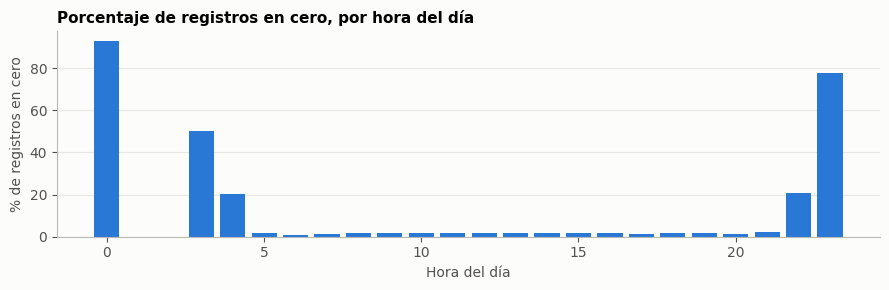

Ceros entre las 5:00 y las 21:00: 1.6%


In [11]:
llave = ["codigo", "fecha", "franja_min"]
print("Valores nulos:", int(datos.isna().sum().sum()))
print("Registros repetidos (estación, fecha, franja):", int(datos.duplicated(llave).sum()))
print("Registros con cero validaciones: {:.1%}".format((datos.validaciones == 0).mean()))

cob = datos.groupby("codigo").agg(estacion=("estacion", "first"), dias=("fecha", "nunique"),
                                  franjas=("franja_min", "nunique"), registros=("fecha", "size"))
incompletas = cob[cob.dias < datos.fecha.nunique()]
print(f"\nEstaciones con datos en todos los días: {len(cob) - len(incompletas)} de {len(cob)}")
if len(incompletas):
    print("Estaciones con días faltantes:"); display(incompletas.sort_values("dias"))

ceros = (datos.assign(hora_ent=datos.franja_min // 60, cero=datos.validaciones == 0)
              .groupby("hora_ent").cero.mean() * 100)
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(ceros.index, ceros.values, color=AZUL, width=0.8)
ax.set_title("Porcentaje de registros en cero, por hora del día")
ax.set_ylabel("% de registros en cero"); ax.set_xlabel("Hora del día"); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.savefig(FIG / "ceros_por_hora.png", dpi=120); plt.show()
print("Ceros entre las 5:00 y las 21:00: {:.1%}".format(
      (datos[(datos.franja_min >= 300) & (datos.franja_min < 1260)].validaciones == 0).mean()))

### 2.2 Variables derivadas
Se construyen aquí porque el resto de la exploración las usa.

In [12]:
datos["hora"] = datos.franja_min / 60
datos["franja"] = datos.franja_min.apply(lambda m: f"{m // 60:02d}:{m % 60:02d}")
datos["dia_semana"] = datos.fecha.dt.dayofweek
datos["festivo"] = datos.fecha.isin(FESTIVOS).astype(int)
datos["tipo_dia"] = np.select(
    [(datos.dia_semana == 6) | (datos.festivo == 1), datos.dia_semana == 5],
    ["domingo_festivo", "sabado"], default="habil")
datos["grupo"] = datos.codigo + "|" + datos.tipo_dia                 # para splines
datos["celda"] = datos.grupo + "|" + datos.franja_min.astype(str)    # estación x tipo de día x franja
datos["celda_dia"] = (datos.codigo + "|" + datos.dia_semana.astype(str) + "|"
                      + datos.franja_min.astype(str))                # estación x día de la semana x franja
datos["fin_de_semana"] = (datos.dia_semana >= 5).astype(int)
datos["troncal"] = datos.linea.str.replace(r"^\(\d+\)\s*Zona\s+\w+\s+", "", regex=True)   # "(33) Zona B AutoNorte" -> "AutoNorte"
datos["y"] = np.log1p(datos.validaciones)

NUMERICAS = ["accesos"]
if oferta is not None:
    datos = datos.merge(oferta, on=["codigo", "tipo_dia", "franja_min"], how="left")
    datos[["buses", "rutas"]] = datos[["buses", "rutas"]].fillna(0)
    datos = datos.merge(ubicacion, on="codigo", how="left")
    NUMERICAS += ["buses", "rutas"]
else:
    datos["lat"], datos["lon"] = np.nan, np.nan
HAY_UBICACION = datos.lat.notna().any()

print("Troncales:", sorted(datos.troncal.unique()))
pd.DataFrame({"variable": ["validaciones (objetivo, en logaritmo)", "troncal", "estación (codigo)", "hora (franja de 15 min)",
                           "tipo_dia / fin_de_semana / festivo / dia_semana", "rutas en la franja",
                           "buses programados en la franja", "accesos", "lat, lon"],
              "tipo": ["numérica", "categórica", "categórica", "numérica", "categórica", "numérica",
                       "numérica", "numérica", "numérica"],
              "origen": ["Excel", "Excel", "Excel", "Excel", "Excel (fecha)", "GTFS", "GTFS", "Excel", "GTFS"],
              "disponible": [True, True, True, True, True, oferta is not None, oferta is not None, True, HAY_UBICACION]})

Troncales: ['AutoNorte', 'Calle 26', 'NQS Sur']


,variable,tipo,origen,disponible
0,"validaciones (objetivo, en logaritmo)",numérica,Excel,True
1,troncal,categórica,Excel,True
2,estación (codigo),categórica,Excel,True
3,hora (franja de 15 min),numérica,Excel,True
4,tipo_dia / fin_de_semana / festivo / dia_semana,categórica,Excel (fecha),True
5,rutas en la franja,numérica,GTFS,True
6,buses programados en la franja,numérica,GTFS,True
7,accesos,numérica,Excel,True
8,"lat, lon",numérica,GTFS,True


### 2.3 Distribución de la variable objetivo

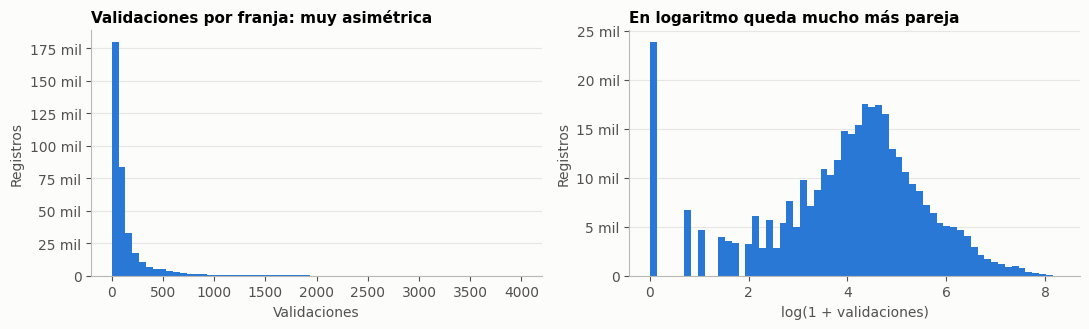

Asimetría original: 4.75 | en logaritmo: -0.68


,25 %,mediana,75 %,90 %,99 %,máximo
validaciones por franja,22.0,67.0,145.0,341.0,1327.0,4000.0


El 10 % de las franjas con más gente concentra el 51% de todas las validaciones.


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(datos.validaciones, bins=60, color=AZUL); ax[0].set_title("Validaciones por franja: muy asimétrica")
ax[1].hist(np.log1p(datos.validaciones), bins=60, color=AZUL); ax[1].set_title("En logaritmo queda mucho más pareja")
ax[0].set_xlabel("Validaciones"); ax[1].set_xlabel("log(1 + validaciones)")
for a in ax:
    a.set_ylabel("Registros"); a.yaxis.set_major_formatter(miles); a.grid(axis="x", visible=False)
plt.tight_layout(); plt.savefig(FIG / "distribucion_objetivo.png", dpi=120); plt.show()

print("Asimetría original: {:.2f} | en logaritmo: {:.2f}".format(
      datos.validaciones.skew(), np.log1p(datos.validaciones).skew()))
cuantiles = datos.validaciones.quantile([0.25, 0.5, 0.75, 0.9, 0.99, 1]).round(0)
cuantiles.index = ["25 %", "mediana", "75 %", "90 %", "99 %", "máximo"]
display(cuantiles.to_frame("validaciones por franja").T)
print("El 10 % de las franjas con más gente concentra el {:.0%} de todas las validaciones.".format(
      datos.validaciones[datos.validaciones >= datos.validaciones.quantile(0.9)].sum() / datos.validaciones.sum()))

### 2.4 La demanda día a día
Cada punto es un día completo, sumando todas las estaciones de las tres zonas.

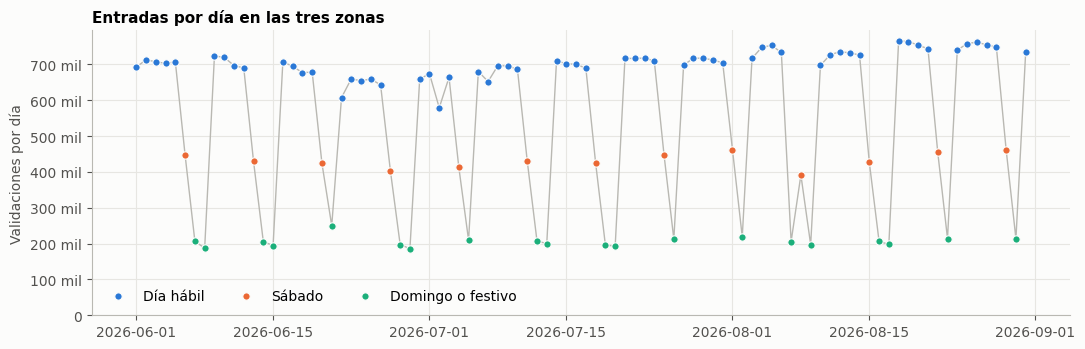

Sábado: 61% de la demanda de un día hábil
Domingo o festivo: 29% de la demanda de un día hábil
Día hábil más alto: 2026-08-18 (766.257) | más bajo: 2026-07-02 (579.142)
Variación entre días hábiles (desviación / promedio): 5.3%


In [14]:
diario = datos.groupby("fecha").agg(validaciones=("validaciones", "sum"), tipo_dia=("tipo_dia", "first"))
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(diario.index, diario.validaciones, color=GRIS, linewidth=1, zorder=1)
for t in ["habil", "sabado", "domingo_festivo"]:
    g = diario[diario.tipo_dia == t]
    ax.scatter(g.index, g.validaciones, s=28, color=COLOR_DIA[t], label=NOMBRE_DIA[t], zorder=2,
               edgecolor="#fcfcfb", linewidth=0.8)
ax.set_title("Entradas por día en las tres zonas"); ax.set_ylabel("Validaciones por día")
ax.yaxis.set_major_formatter(miles); ax.set_ylim(0); ax.legend(ncol=3, loc="lower left")
plt.tight_layout(); plt.savefig(FIG / "serie_diaria.png", dpi=120); plt.show()

prom = diario.groupby("tipo_dia").validaciones.mean()
for t in ["sabado", "domingo_festivo"]:
    if t in prom and "habil" in prom:
        print(f"{NOMBRE_DIA[t]}: {prom[t] / prom['habil']:.0%} de la demanda de un día hábil")
hab = diario[diario.tipo_dia == "habil"].validaciones
print(f"Día hábil más alto: {hab.idxmax().date()} ({hab.max():,.0f}) | más bajo: {hab.idxmin().date()} ({hab.min():,.0f})".replace(",", "."))
print("Variación entre días hábiles (desviación / promedio): {:.1%}".format(hab.std() / hab.mean()))

### 2.5 Por día de la semana (estaciones de estudio)
Promedio de entradas por día, sin contar los festivos.

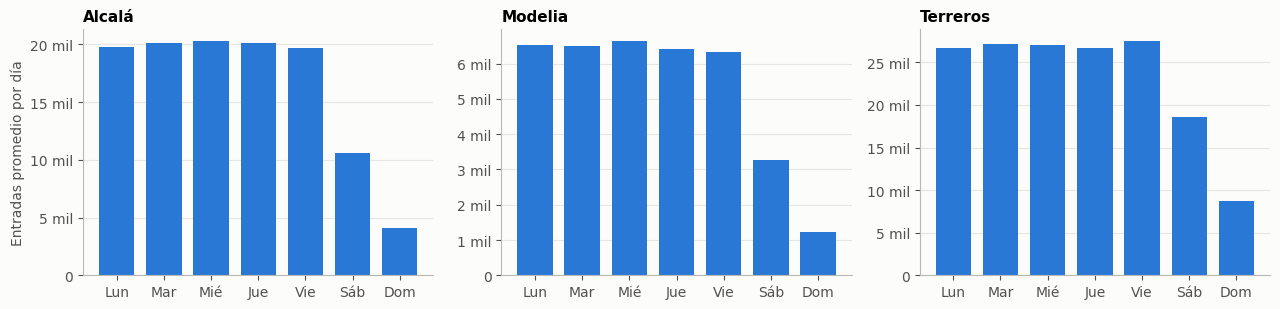

,Lun,Mar,Mié,Jue,Vie,Sáb,Dom,domingo / lunes a viernes
estacion,,,,,,,,
Alcalá,19730,20128,20277,20132,19663,10549,4061,0.20
Modelia,6535,6498,6641,6426,6331,3254,1235,0.19
Terreros,26648,27157,27083,26708,27508,18609,8673,0.32


In [15]:
sin_festivos = datos[datos.estudio & (datos.festivo == 0)]
por_dia = (sin_festivos.groupby(["estacion", "fecha", "dia_semana"]).validaciones.sum()
           .groupby(["estacion", "dia_semana"]).mean().unstack("estacion"))
est = [e for e in ESTUDIO.values() if e in por_dia.columns]
fig, ax = plt.subplots(1, len(est), figsize=(4.3 * len(est), 3.2), squeeze=False)
for a, e in zip(ax[0], est):
    a.bar(range(7), por_dia[e].reindex(range(7)).values, color=AZUL, width=0.75)
    a.set_xticks(range(7)); a.set_xticklabels(DIAS); a.set_title(e)
    a.yaxis.set_major_formatter(miles); a.grid(axis="x", visible=False)
ax[0][0].set_ylabel("Entradas promedio por día")
plt.tight_layout(); plt.savefig(FIG / "dia_semana.png", dpi=120); plt.show()

tabla = (por_dia[est].reindex(range(7)).set_axis(DIAS).round(0).astype(int).T)
tabla["domingo / lunes a viernes"] = (por_dia[est].loc[6] / por_dia[est].loc[0:4].mean()).round(2).values
display(tabla)

### 2.6 Por hora del día y tipo de día (estaciones de estudio)
Esta gráfica es la evidencia principal para decidir si splines y kernels aportan: la relación con la hora no es una recta y cambia de una estación a otra.

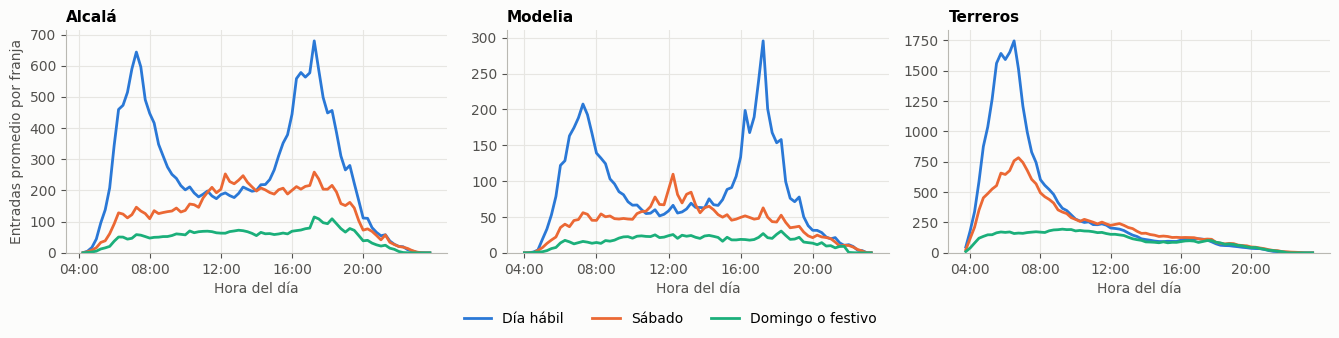

Alcalá: pico de la mañana a las 07:15 (644) | pico de la tarde a las 17:15 (680)
Modelia: pico de la mañana a las 07:15 (208) | pico de la tarde a las 17:15 (296)
Terreros: pico de la mañana a las 06:30 (1745) | pico de la tarde a las 12:00 (205)


In [16]:
perfil = datos[datos.estudio].groupby(["estacion", "tipo_dia", "hora"]).validaciones.mean().reset_index()
est = [e for e in ESTUDIO.values() if e in set(perfil.estacion)]
fig, ax = plt.subplots(1, len(est), figsize=(4.5 * len(est), 3.4), squeeze=False)
for a, e in zip(ax[0], est):
    for t in ["habil", "sabado", "domingo_festivo"]:
        g = perfil[(perfil.estacion == e) & (perfil.tipo_dia == t)]
        a.plot(g.hora, g.validaciones, color=COLOR_DIA[t], label=NOMBRE_DIA[t])
    a.set_title(e); eje_horas(a); a.set_ylim(0)
ax[0][0].set_ylabel("Entradas promedio por franja")
fig.legend(*ax[0][0].get_legend_handles_labels(), loc="lower center", ncol=3)
plt.tight_layout(rect=(0, 0.07, 1, 1)); plt.savefig(FIG / "perfil_horario.png", dpi=120); plt.show()

hab = perfil[perfil.tipo_dia == "habil"]
for e in est:
    g = hab[hab.estacion == e].set_index("hora").validaciones
    am, pm = g[g.index < 12], g[g.index >= 12]
    print(f"{e}: pico de la mañana a las {int(am.idxmax()):02d}:{int(am.idxmax() % 1 * 60):02d} ({am.max():.0f}) | "
          f"pico de la tarde a las {int(pm.idxmax()):02d}:{int(pm.idxmax() % 1 * 60):02d} ({pm.max():.0f})")

### 2.7 Hora y día de la semana a la vez
Cada cuadro es el promedio de entradas en esa franja y ese día. Más oscuro es más gente.

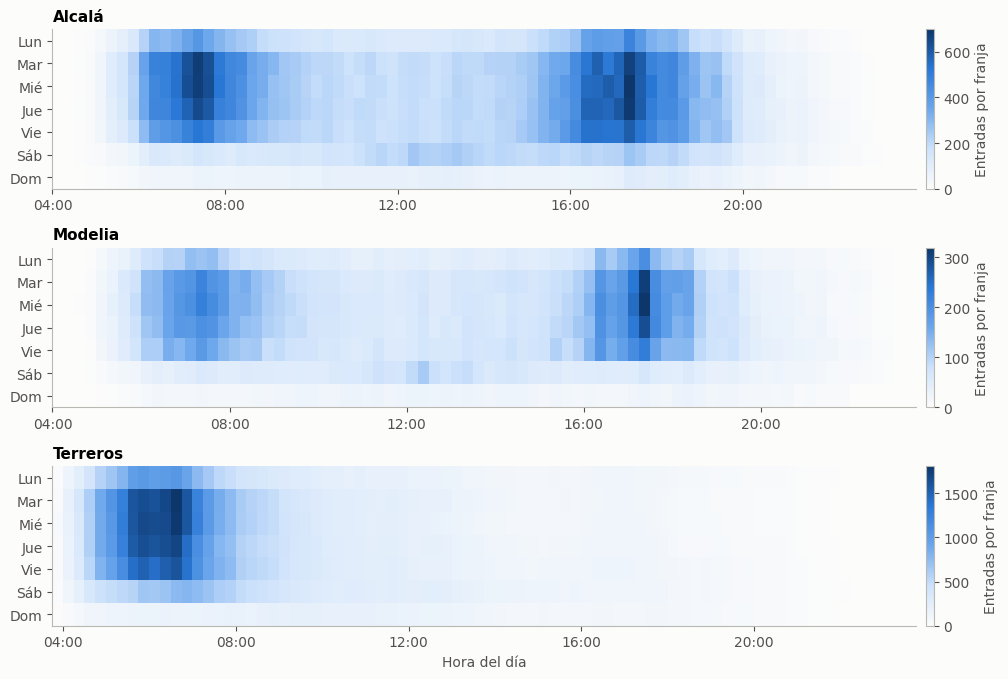

In [17]:
est = [e for e in ESTUDIO.values() if e in set(datos.estacion[datos.estudio])]
fig, ax = plt.subplots(len(est), 1, figsize=(11, 2.3 * len(est)), squeeze=False)
for a, e in zip(ax[:, 0], est):
    m = (datos[datos.estacion == e].groupby(["dia_semana", "hora"]).validaciones.mean()
         .unstack("hora").reindex(range(7)))
    im = a.imshow(m.values, aspect="auto", cmap=MAPA_AZUL, vmin=0,
                  extent=[m.columns.min(), m.columns.max() + 0.25, 6.5, -0.5])
    a.set_yticks(range(7)); a.set_yticklabels(DIAS); a.set_title(e); a.grid(False)
    eje_horas(a); a.set_xlabel("")
    fig.colorbar(im, ax=a, pad=0.01).set_label("Entradas por franja")
ax[-1, 0].set_xlabel("Hora del día")
plt.tight_layout(); plt.savefig(FIG / "mapa_hora_dia.png", dpi=120); plt.show()

### 2.8 Las estaciones no son iguales: tamaño
Entradas promedio en un día hábil. En azul, las tres estaciones de estudio.

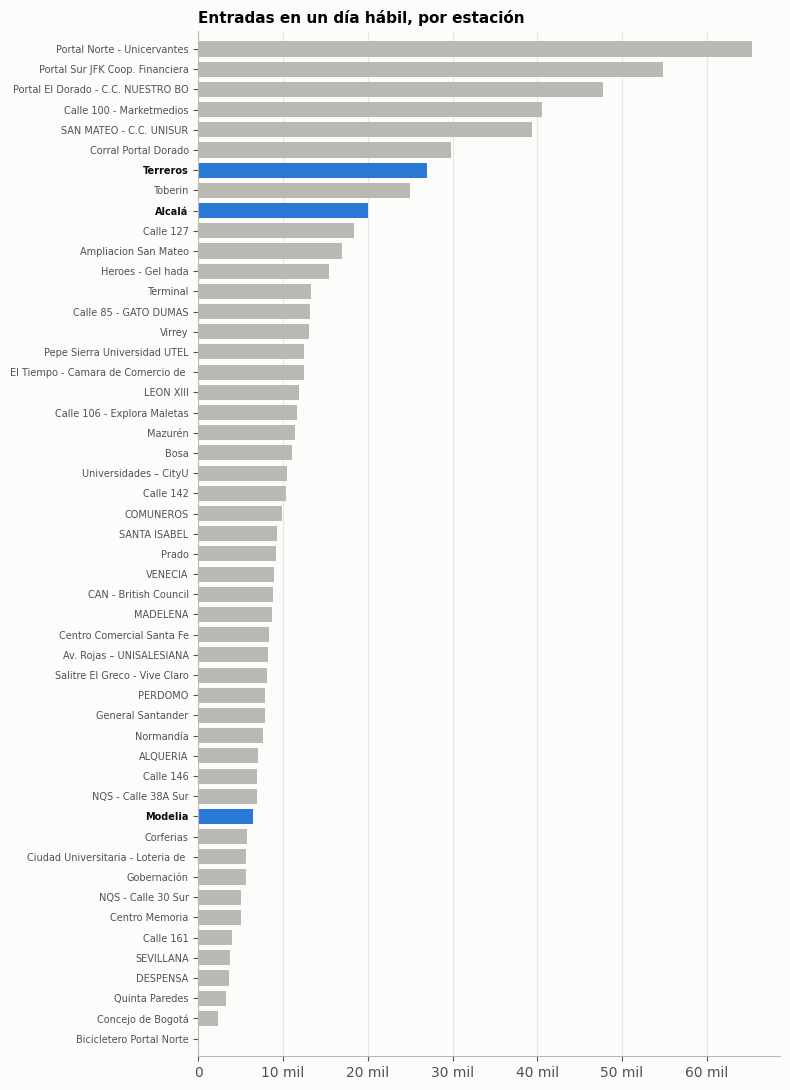

Terreros: puesto 7 de 50, con 27.044 entradas en un día hábil
Alcalá: puesto 9 de 50, con 20.013 entradas en un día hábil
Modelia: puesto 39 de 50, con 6.485 entradas en un día hábil
Las 5 estaciones más grandes concentran el 35% de las entradas; la más grande recibe 2584 veces lo que la más pequeña.


In [18]:
tam = (datos[datos.tipo_dia == "habil"].groupby(["estacion", "estudio", "fecha"]).validaciones.sum()
       .groupby(["estacion", "estudio"]).mean().reset_index().sort_values("validaciones"))
fig, ax = plt.subplots(figsize=(8, 0.2 * len(tam) + 1))
ax.barh(tam.estacion.str.slice(0, 34), tam.validaciones, color=np.where(tam.estudio, AZUL, GRIS), height=0.75)
ax.set_title("Entradas en un día hábil, por estación"); ax.xaxis.set_major_formatter(miles)
ax.grid(axis="y", visible=False); ax.tick_params(axis="y", labelsize=7); ax.margins(y=0.01)
for etiqueta, es in zip(ax.get_yticklabels(), tam.estudio):
    if es:
        etiqueta.set_fontweight("bold"); etiqueta.set_color("#0b0b0b")
plt.tight_layout(); plt.savefig(FIG / "ranking_estaciones.png", dpi=120); plt.show()

orden = tam.sort_values("validaciones", ascending=False).reset_index(drop=True)
for _, f in orden[orden.estudio].iterrows():
    print(f"{f.estacion}: puesto {orden.index[orden.estacion == f.estacion][0] + 1} de {len(orden)}, con "
          + f"{f.validaciones:,.0f}".replace(",", ".") + " entradas en un día hábil")
print("Las 5 estaciones más grandes concentran el {:.0%} de las entradas; la más grande recibe {:.0f} veces lo que la más pequeña.".format(
      orden.validaciones.head(5).sum() / orden.validaciones.sum(), orden.validaciones.max() / orden.validaciones.min()))

### 2.9 Las estaciones no son iguales: forma del día
Para cada estación se calcula qué parte de las entradas de un día hábil ocurre antes del mediodía.

- **Porcentaje alto:** la gente entra en la mañana. Es una estación de origen, cerca de donde la gente vive.
- **Porcentaje bajo:** la gente entra en la tarde. Es una estación de destino, cerca de donde la gente trabaja o estudia.

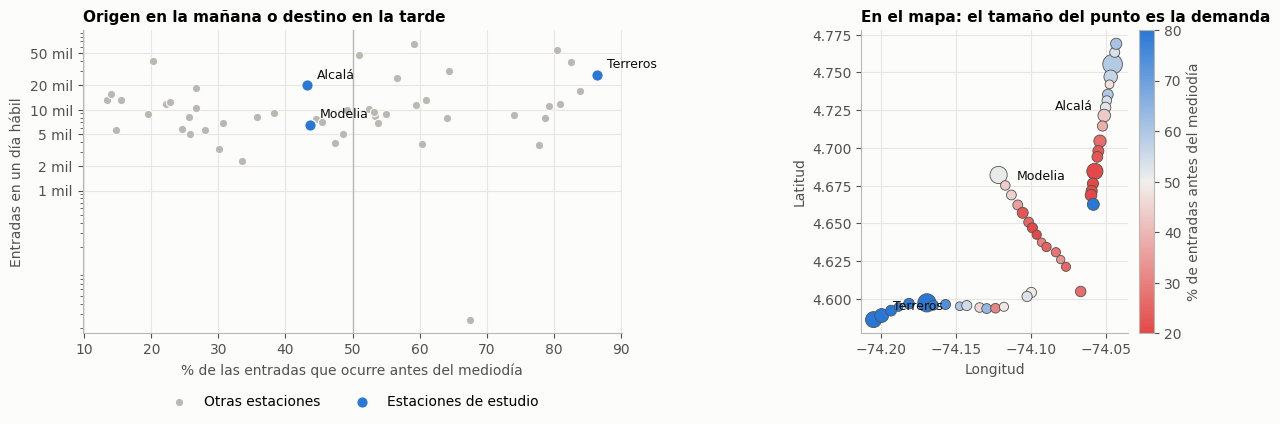

,pct_manana,entradas_dia
estacion,,
Alcalá,43.2,20013.3
Modelia,43.7,6484.9
Terreros,86.5,27044.1


Estaciones con más del 60 % en la mañana: 14 | con menos del 40 %: 20 | intermedias: 16


In [19]:
hab = datos[datos.tipo_dia == "habil"]
forma = hab.groupby(["codigo", "estacion", "estudio"]).apply(
    lambda g: pd.Series({"pct_manana": 100 * g.validaciones[g.hora < 12].sum() / max(g.validaciones.sum(), 1),
                         "entradas_dia": g.validaciones.sum() / g.fecha.nunique(),
                         "lat": g.lat.iloc[0], "lon": g.lon.iloc[0]})).reset_index()

paneles = 2 if HAY_UBICACION else 1
fig, ax = plt.subplots(1, paneles, figsize=(6.2 * paneles, 4.4), squeeze=False)
a = ax[0][0]
otras, estu = forma[~forma.estudio], forma[forma.estudio]
a.scatter(otras.pct_manana, otras.entradas_dia, s=36, color=GRIS, edgecolor="#fcfcfb", linewidth=0.8, label="Otras estaciones")
a.scatter(estu.pct_manana, estu.entradas_dia, s=70, color=AZUL, edgecolor="#fcfcfb", linewidth=1, label="Estaciones de estudio")
for _, f in estu.iterrows():
    a.annotate(f.estacion, (f.pct_manana, f.entradas_dia), xytext=(7, 5), textcoords="offset points", fontsize=9, color="#0b0b0b")
a.axvline(50, color=GRIS, linewidth=1); a.set_yscale("log")
a.set_yticks([t for t in [1000, 2000, 5000, 10000, 20000, 50000, 100000]
              if forma.entradas_dia.min() / 1.5 <= t <= forma.entradas_dia.max() * 1.5])
a.yaxis.set_major_formatter(miles); a.yaxis.set_minor_formatter(lambda x, _: "")
a.set_xlabel("% de las entradas que ocurre antes del mediodía"); a.set_ylabel("Entradas en un día hábil")
a.set_title("Origen en la mañana o destino en la tarde")
a.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)

if HAY_UBICACION:
    b, u = ax[0][1], forma.dropna(subset=["lat", "lon"])
    sc = b.scatter(u.lon, u.lat, c=u.pct_manana, cmap=MAPA_DIVERGENTE, vmin=20, vmax=80,
                   s=30 + 170 * u.entradas_dia / u.entradas_dia.max(), edgecolor=TINTA, linewidth=0.6)
    for _, f in u[u.estudio].iterrows():
        izq = f.lon > u.lon.median()                      # la etiqueta va hacia el lado con más espacio
        b.annotate(f.estacion, (f.lon, f.lat), xytext=(-8 if izq else 8, 4), ha="right" if izq else "left",
                   textcoords="offset points", fontsize=9, color="#0b0b0b")
    b.set_aspect(1 / np.cos(np.radians(4.65))); b.set_xlabel("Longitud"); b.set_ylabel("Latitud")
    b.set_title("En el mapa: el tamaño del punto es la demanda")
    fig.colorbar(sc, ax=b, pad=0.02).set_label("% de entradas antes del mediodía")
plt.tight_layout(); plt.savefig(FIG / "forma_del_dia.png", dpi=120); plt.show()
display(estu.set_index("estacion")[["pct_manana", "entradas_dia"]].round(1))
print("Estaciones con más del 60 % en la mañana:", int((forma.pct_manana > 60).sum()),
      "| con menos del 40 %:", int((forma.pct_manana < 40).sum()), "| intermedias:", int(forma.pct_manana.between(40, 60).sum()))

### 2.10 Qué tan estable es el patrón
Para cada franja de un día hábil: la línea es la mediana y la banda cubre desde el 10 % hasta el 90 % de los días. Una banda angosta significa que esa franja se repite casi igual todos los días.

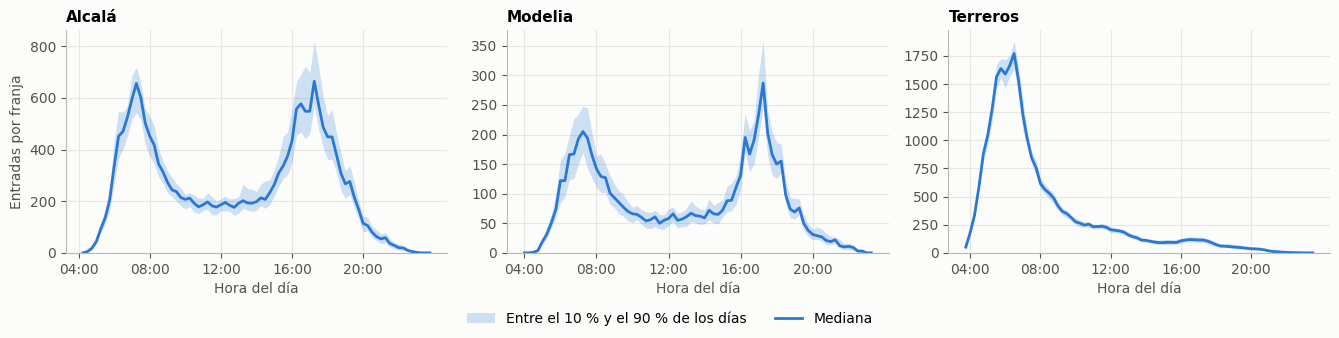

Alcalá: en su franja pico (17:15) entran entre 571 y 820 personas; ancho típico de la banda: 39% de la mediana
Modelia: en su franja pico (17:15) entran entre 245 y 358 personas; ancho típico de la banda: 46% de la mediana
Terreros: en su franja pico (06:30) entran entre 1632 y 1883 personas; ancho típico de la banda: 24% de la mediana


In [20]:
hab = datos[datos.estudio & (datos.tipo_dia == "habil")]
q = hab.groupby(["estacion", "hora"]).validaciones.quantile([0.1, 0.5, 0.9]).unstack()
est = [e for e in ESTUDIO.values() if e in q.index.get_level_values(0)]
fig, ax = plt.subplots(1, len(est), figsize=(4.5 * len(est), 3.4), squeeze=False)
for a, e in zip(ax[0], est):
    g = q.loc[e]
    a.fill_between(g.index, g[0.1], g[0.9], color=AZUL, alpha=0.22, linewidth=0, label="Entre el 10 % y el 90 % de los días")
    a.plot(g.index, g[0.5], color=AZUL, label="Mediana")
    a.set_title(e); eje_horas(a); a.set_ylim(0)
ax[0][0].set_ylabel("Entradas por franja")
fig.legend(*ax[0][0].get_legend_handles_labels(), loc="lower center", ncol=2)
plt.tight_layout(rect=(0, 0.07, 1, 1)); plt.savefig(FIG / "estabilidad.png", dpi=120); plt.show()

for e in est:
    g = q.loc[e]; pico = g[0.5].idxmax()
    ancho = (g[0.9] - g[0.1]) / g[0.5].where(g[0.5] > 20)
    print(f"{e}: en su franja pico ({int(pico):02d}:{int(pico % 1 * 60):02d}) entran entre {g.loc[pico, 0.1]:.0f} y "
          f"{g.loc[pico, 0.9]:.0f} personas; ancho típico de la banda: {ancho.median():.0%} de la mediana")

### 2.11 Días atípicos
Se compara cada día de cada estación con los demás días del mismo tipo en esa estación. Un día es atípico si se aleja más de 3,5 desviaciones robustas de la mediana.

In [21]:
dia_est = datos.groupby(["codigo", "estacion", "estudio", "fecha", "tipo_dia"], as_index=False).validaciones.sum()
g = dia_est.groupby(["codigo", "tipo_dia"]).validaciones
dia_est["mediana"] = g.transform("median")
mad = g.transform(lambda s: (s - s.median()).abs().median())
dia_est["z"] = 0.6745 * (dia_est.validaciones - dia_est.mediana) / mad.where(mad > 0)
dia_est["diferencia_%"] = (100 * (dia_est.validaciones / dia_est.mediana.where(dia_est.mediana > 0) - 1)).round(0)
atipicos = dia_est[dia_est.z.abs() > 3.5]

print(f"Días atípicos: {len(atipicos)} de {len(dia_est)} combinaciones de estación y día ({len(atipicos) / len(dia_est):.1%})")
print("Por debajo de lo normal:", int((atipicos.z < 0).sum()), "| por encima:", int((atipicos.z > 0).sum()))
print("\nFechas con más estaciones atípicas a la vez:")
display(atipicos.groupby("fecha").agg(estaciones=("codigo", "nunique"), diferencia_mediana=("diferencia_%", "median"),
                                      tipo_dia=("tipo_dia", "first")).sort_values("estaciones", ascending=False).head(8))
print("Días atípicos en las estaciones de estudio:")
display(atipicos[atipicos.estudio].sort_values("z")[["estacion", "fecha", "tipo_dia", "validaciones", "mediana", "diferencia_%"]].head(12))
atipicos.to_csv(PROC / "dias_atipicos.csv", index=False)

Días atípicos: 94 de 4600 combinaciones de estación y día (2.0%)
Por debajo de lo normal: 49 | por encima: 45

Fechas con más estaciones atípicas a la vez:


,estaciones,diferencia_mediana,tipo_dia
fecha,,,
2026-06-21,15,38.0,domingo_festivo
2026-07-02,12,-36.0,habil
2026-06-22,8,-17.5,habil
2026-08-08,4,-19.5,sabado
2026-07-26,3,40.0,domingo_festivo
2026-08-23,3,67.0,domingo_festivo
2026-06-24,2,-22.5,habil
2026-08-01,2,30.5,sabado


Días atípicos en las estaciones de estudio:


,estacion,fecha,tipo_dia,validaciones,mediana,diferencia_%
4171,Terreros,2026-07-02,habil,17298.0,27335.0,-37.0
4163,Terreros,2026-06-24,habil,23953.0,27335.0,-12.0
4161,Terreros,2026-06-22,habil,24453.0,27335.0,-11.0
4208,Terreros,2026-08-08,sabado,16525.0,18932.0,-13.0
1769,Modelia,2026-06-22,habil,5113.0,6645.0,-23.0
4160,Terreros,2026-06-21,domingo_festivo,10963.0,8362.0,31.0


### 2.12 ¿Se parece esta semana a la anterior?
Cada punto compara una franja con la misma franja, en la misma estación, siete días antes. Si los puntos siguen la diagonal, el patrón semanal se repite y un modelo puede aprenderlo.

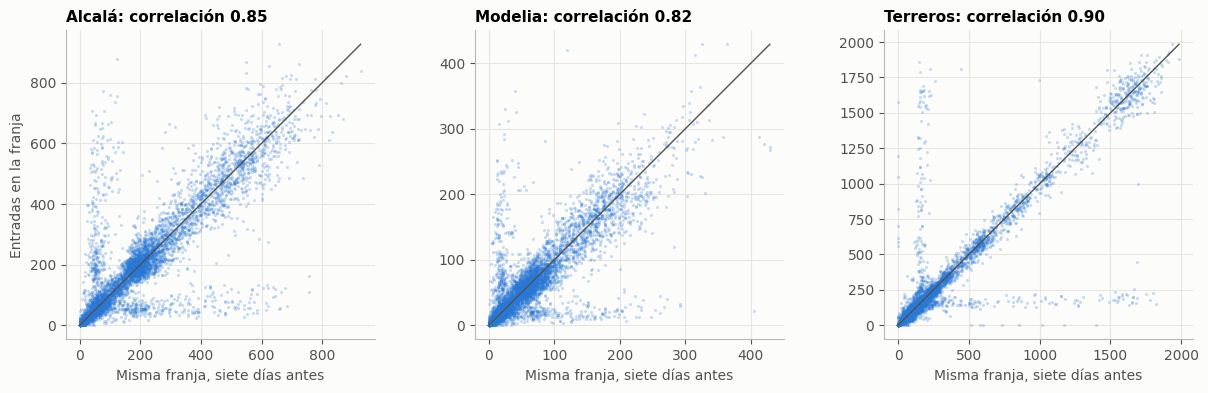

Si se predijera cada franja con el valor de siete días antes, el error promedio sería de 40.0 pasajeros por franja en las estaciones de estudio.


estacion,Alcalá,Modelia,Terreros
error promedio (pasajeros),47.8,18.7,53.0


In [22]:
s = datos.loc[datos.estudio, ["estacion", "fecha", "franja_min", "validaciones"]]
antes = s.assign(fecha=s.fecha + pd.Timedelta(days=7)).rename(columns={"validaciones": "semana_anterior"})
par = s.merge(antes, on=["estacion", "fecha", "franja_min"])
est = [e for e in ESTUDIO.values() if e in set(par.estacion)]
fig, ax = plt.subplots(1, len(est), figsize=(4.2 * len(est), 3.9), squeeze=False)
for a, e in zip(ax[0], est):
    g = par[par.estacion == e]; tope = max(g.validaciones.max(), g.semana_anterior.max())
    a.scatter(g.semana_anterior, g.validaciones, s=5, color=AZUL, alpha=0.25, linewidth=0)
    a.plot([0, tope], [0, tope], color=TINTA, linewidth=1)
    a.set_title(f"{e}: correlación {g.validaciones.corr(g.semana_anterior):.2f}")
    a.set_xlabel("Misma franja, siete días antes"); a.set_aspect("equal")
ax[0][0].set_ylabel("Entradas en la franja")
plt.tight_layout(); plt.savefig(FIG / "semana_anterior.png", dpi=120); plt.show()

dif = (par.validaciones - par.semana_anterior).abs()
print("Si se predijera cada franja con el valor de siete días antes, el error promedio sería de",
      f"{dif.mean():.1f} pasajeros por franja en las estaciones de estudio.")
display(par.assign(error=dif).groupby("estacion").error.mean().round(1).to_frame("error promedio (pasajeros)").T)

### 2.13 Demanda, oferta de buses y correlaciones
La tabla sirve para argumentar si Ridge y Lasso tienen multicolinealidad que tratar.

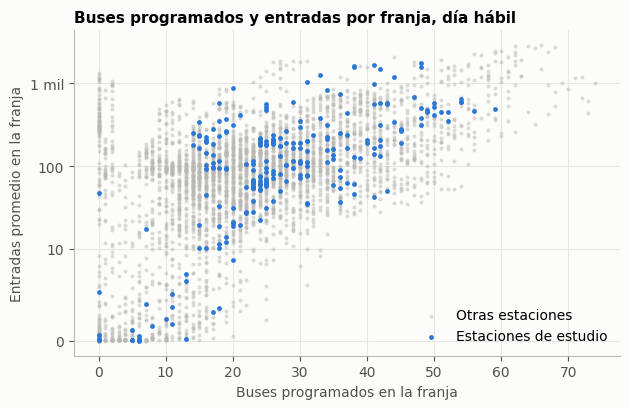

Correlación entre buses programados y entradas (día hábil, por estación y franja): 0.46


,y,hora,dia_semana,festivo,accesos,buses,rutas,lat,lon
y,1.00,-0.22,-0.10,-0.15,0.44,0.58,0.53,0.08,-0.02
hora,-0.22,1.00,-0.00,0.00,-0.05,-0.07,0.03,0.01,0.01
dia_semana,-0.10,-0.00,1.00,-0.34,0.00,-0.15,-0.12,-0.00,-0.00
festivo,-0.15,0.00,-0.34,1.00,-0.00,-0.18,-0.17,0.00,0.00
accesos,0.44,-0.05,0.00,-0.00,1.00,0.42,0.56,0.07,-0.04
buses,0.58,-0.07,-0.15,-0.18,0.42,1.00,0.91,0.23,0.14
rutas,0.53,0.03,-0.12,-0.17,0.56,0.91,1.00,0.25,0.13
lat,0.08,0.01,-0.00,0.00,0.07,0.23,0.25,1.00,0.81
lon,-0.02,0.01,-0.00,0.00,-0.04,0.14,0.13,0.81,1.00


Pares de variables explicativas con correlación mayor a 0,7:
buses  rutas    0.91
lat    lon      0.81


In [23]:
if "buses" in datos:
    m = (datos[datos.tipo_dia == "habil"].groupby(["codigo", "estudio", "franja_min"])
         .agg(validaciones=("validaciones", "mean"), buses=("buses", "mean")).reset_index())
    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    ax.scatter(m.buses[~m.estudio], m.validaciones[~m.estudio], s=8, color=GRIS, alpha=0.5, linewidth=0, label="Otras estaciones")
    ax.scatter(m.buses[m.estudio], m.validaciones[m.estudio], s=12, color=AZUL, linewidth=0, label="Estaciones de estudio")
    ax.set_yscale("symlog", linthresh=10); ax.yaxis.set_major_formatter(miles)
    ax.set_xlabel("Buses programados en la franja"); ax.set_ylabel("Entradas promedio en la franja")
    ax.set_title("Buses programados y entradas por franja, día hábil"); ax.legend(loc="lower right")
    plt.tight_layout(); plt.savefig(FIG / "oferta_demanda.png", dpi=120); plt.show()
    print("Correlación entre buses programados y entradas (día hábil, por estación y franja): {:.2f}".format(
          m.buses.corr(m.validaciones)))

cols = ["y", "hora", "dia_semana", "festivo"] + NUMERICAS + (["lat", "lon"] if HAY_UBICACION else [])
corr = datos[cols].corr().round(2)
display(corr)
pares = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack()
altos = pares[(pares.abs() > 0.7) & (pares.index.get_level_values(0) != "y")]
print("Pares de variables explicativas con correlación mayor a 0,7:")
print(altos.to_string() if len(altos) else "  ninguno")

### 2.14 Qué aprendimos y qué decidimos

| Hallazgo | Evidencia | Consecuencia para el modelo |
|---|---|---|
| La variable objetivo es muy asimétrica | Asimetría de 4,75 que baja a -0,68 en logaritmo. El 10 % de las franjas concentra el 51 % de las validaciones (2.3) | Se modela log(1 + validaciones) |
| Los ceros son de apertura y cierre | 6,6 % de ceros en total, pero solo 1,6 % entre 5:00 y 21:00 (2.1) | Se conservan: son parte del servicio |
| El tipo de día cambia el nivel | Un sábado tiene el 61 % de la demanda de un día hábil y un domingo o festivo el 29 % (2.4) | Tipo de día y día de la semana entran como variables |
| Los días hábiles se parecen entre sí | Variación de 5,3 % entre días hábiles (2.4) | El patrón es estable y se puede aprender |
| La hora no tiene relación lineal | Alcalá y Modelia tienen dos picos (7:15 y 17:15); Terreros uno solo, a las 6:30, con 1.745 entradas (2.6) | Splines y kernels sobre la hora |
| Cada estación tiene su propia forma | Terreros recibe el 86 % de sus entradas antes del mediodía; Alcalá y Modelia, el 43 %. Hay 14 estaciones de origen, 20 de destino y 16 mixtas (2.9) | Una curva por estación, no una sola para todas |
| Las estaciones son de tamaños muy distintos | Las 5 más grandes concentran el 35 % de las entradas (2.8) | La estación entra como variable categórica |
| El patrón semanal se repite | Correlación con la semana anterior de 0.85 en Alcalá, 0.82 en Modelia y 0.90 en Terreros; error de 40 pasajeros por franja (2.12) | Variables por estación, día de la semana y franja |
| Hay variables explicativas correlacionadas | Buses y rutas: 0,91. Latitud y longitud: 0,81 (2.13) | Justifica probar Ridge y Lasso |
| Hay días atípicos, y tienen explicación | 2,0 % de los días por estación (94 de 4.600). El 2 de julio una protesta en la Autopista Sur cerró estaciones del sur; el 21 de junio hubo más demanda de la normal en 15 estaciones (2.11) | Se conservan: son eventos reales |
| La exploración detectó un festivo mal marcado | El 13 de julio aparecía como atípico en 48 de 50 estaciones | Se agregó a la lista de festivos |

**Decisiones de limpieza**

| Decisión | Qué se hizo | Por qué |
|---|---|---|
| Filas vacías y "Total general" | Se eliminan en la carga | No son observaciones |
| Rutas duales (línea sin "Zona") | Se excluyen | Son buses en vía, no estaciones |
| Columna sobrante del archivo de junio | Se descarta en la carga y se unifican los repetidos en la celda 1.3 | El archivo traía 31 columnas para un mes de 30 días |
| Zonas | Solo AutoNorte, Calle 26 y NQS Sur | Contienen las estaciones de estudio y superan los 100.000 registros |
| Ceros | Se mantienen | Son franjas reales de apertura y cierre |
| Días atípicos | Se mantienen | Son eventos reales de la ciudad y el modelo debe convivir con ellos |
| Festivos | Se agregó el 13 de julio | Se comportó como festivo en casi todas las estaciones |
| Transformación del objetivo | log(1 + y) | Reduce la asimetría de 4,75 a -0,68 |

### 2.15 Partición entrenamiento / prueba
La partición es **estratificada por estación y agrupada por fecha**:

- cada estación queda con el mismo porcentaje de sus datos en entrenamiento y en prueba;
- ninguna fecha se reparte entre los dos conjuntos, para que el modelo no vea en entrenamiento el mismo día que se le pregunta en prueba.

La validación cruzada usa la misma regla dentro del entrenamiento.

In [24]:
# Partición estratificada por estación y agrupada por fecha
particion = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
i_train, i_test = next(particion.split(datos, y=datos.codigo, groups=datos.fecha))
train, test = datos.iloc[i_train].copy(), datos.iloc[i_test].copy()
X_train, y_train, grupos_train = train, train.y, train.fecha
X_test, y_test = test, test.y

# Pliegues de validación cruzada, con la misma regla, solo dentro de entrenamiento
PLIEGUES = list(StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
                .split(train, y=train.codigo, groups=train.fecha))

assert not set(train.fecha) & set(test.fecha), "Hay fechas en entrenamiento y en prueba a la vez"
print(f"Entrenamiento: {len(train):,} registros en {train.fecha.nunique()} días".replace(",", "."))
print(f"Prueba:        {len(test):,} registros en {test.fecha.nunique()} días "
      f"({len(test) / len(datos):.1%} del total)".replace(",", "."))
print("Fechas de prueba:", ", ".join(d.strftime("%d-%b") for d in sorted(test.fecha.unique())))

# Verificación 1: cada estación queda con el mismo porcentaje en prueba
pct = (test.groupby("codigo").size() / datos.groupby("codigo").size() * 100).rename("% en prueba")
print(f"\n% de cada estación que quedó en prueba: mínimo {pct.min():.1f}, máximo {pct.max():.1f}")
display(pct[list(ESTUDIO)].rename(index=ESTUDIO).round(1).to_frame().T)

# Verificación 2: mezcla de tipos de día (no se estratificó por esto; conviene mirarla)
mezcla = pd.DataFrame({"entrenamiento": train.groupby("tipo_dia").fecha.nunique(),
                       "prueba": test.groupby("tipo_dia").fecha.nunique()}).fillna(0).astype(int)
mezcla.loc["total"] = mezcla.sum()
print("Días de cada tipo:"); display(mezcla)

# Verificación 3: los pliegues
info = []
for k, (a, b) in enumerate(PLIEGUES, 1):
    val = train.iloc[b]
    p = val.groupby("codigo").size() / train.groupby("codigo").size() * 100
    info.append({"pliegue": k, "registros de validación": len(val), "días": val.fecha.nunique(),
                 "% por estación (mín)": round(p.min(), 1), "% por estación (máx)": round(p.max(), 1),
                 "días hábiles": val.loc[val.tipo_dia == "habil", "fecha"].nunique()})
display(pd.DataFrame(info).set_index("pliegue"))

Entrenamiento: 290.566 registros en 74 días
Prueba:        70.668 registros en 18 días (19.6% del total)
Fechas de prueba: 02-Jun, 03-Jun, 16-Jun, 19-Jun, 24-Jun, 27-Jun, 03-Jul, 07-Jul, 12-Jul, 13-Jul, 19-Jul, 29-Jul, 01-Aug, 07-Aug, 10-Aug, 14-Aug, 21-Aug, 25-Aug

% de cada estación que quedó en prueba: mínimo 19.5, máximo 19.6


codigo,Alcalá,Modelia,Terreros
% en prueba,19.6,19.6,19.6


Días de cada tipo:


,entrenamiento,prueba
tipo_dia,,
domingo_festivo,16,4
habil,47,12
sabado,11,2
total,74,18


,registros de validación,días,% por estación (mín),% por estación (máx),días hábiles
pliegue,,,,,
1,58935,15,20.3,20.3,11
2,58881,15,20.2,20.3,8
3,54961,14,18.9,19.0,10
4,58890,15,20.2,20.3,11
5,58899,15,20.2,20.3,7


In [38]:
# ¿Cuántas estaciones quedaron en prueba y con qué porcentaje de sus registros?
print(f"Estaciones en total:         {datos.codigo.nunique()}")
print(f"Estaciones en entrenamiento: {train.codigo.nunique()}")
print(f"Estaciones en prueba:        {test.codigo.nunique()}")
print("Estaciones que faltan en prueba:", sorted(set(datos.codigo) - set(test.codigo)) or "ninguna")

reparto = (datos.groupby(["codigo", "estacion"]).size().rename("total").reset_index()
           .merge(train.groupby("codigo").size().rename("train").reset_index(), on="codigo", how="left")
           .merge(test.groupby("codigo").size().rename("test").reset_index(), on="codigo", how="left")
           .fillna(0))
reparto["% en prueba"] = (reparto.test / reparto.total * 100).round(1)
reparto["días en prueba"] = reparto.codigo.map(test.groupby("codigo").fecha.nunique()).fillna(0).astype(int)

print(f"\n% en prueba por estación: mínimo {reparto['% en prueba'].min()}, "
      f"máximo {reparto['% en prueba'].max()}, promedio {reparto['% en prueba'].mean():.1f}")
print(f"% en prueba del total de registros: {len(test) / len(datos) * 100:.1f}")

display(reparto.sort_values("% en prueba").reset_index(drop=True))

Estaciones en total:         50
Estaciones en entrenamiento: 50
Estaciones en prueba:        50
Estaciones que faltan en prueba: ninguna

% en prueba por estación: mínimo 19.5, máximo 19.6, promedio 19.6
% en prueba del total de registros: 19.6


,codigo,estacion,total,train,test,% en prueba,días en prueba
0,02305,Bicicletero Portal Norte,5741,4619,1122,19.5,18
1,02000,Portal Norte - Unicervantes,7422,5970,1452,19.6,18
2,02101,Toberin,7084,5698,1386,19.6,18
3,02001,Centro Comercial Santa Fe,7115,5723,1392,19.6,18
4,02103,Mazurén,7146,5748,1398,19.6,18
5,02104,Calle 146,7115,5723,1392,19.6,18
6,02105,Calle 142,7208,5798,1410,19.6,18
7,02102,Calle 161,7085,5699,1386,19.6,18
8,02201,Prado,7146,5748,1398,19.6,18
9,02202,Calle 127,7299,5871,1428,19.6,18


## Bloque 3. Fase 3: métodos y matriz de aplicabilidad
Todos los hiperparámetros se eligen con validación cruzada **solo sobre entrenamiento**, con los pliegues formados por fecha. Las métricas de este bloque están en escala logarítmica y sobre todas las estaciones; en el bloque 4 se pasan a pasajeros y se separan las estaciones de estudio.

### 3.0 Herramientas comunes

In [25]:
cv = PLIEGUES        # pliegues definidos en la celda 2.15
SCORING = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}
resultados, modelos, hiper = [], {}, []

def ajustar(nombre, modelo, grid):
    """Busca hiperparámetros por validación cruzada y guarda el resultado."""
    gs = GridSearchCV(modelo, grid, cv=cv, scoring=SCORING, refit="rmse", n_jobs=-1)
    gs.fit(X_train, y_train, groups=grupos_train)
    r, i = gs.cv_results_, gs.best_index_
    resultados.append({"modelo": nombre,
                       "RMSE_cv": -r["mean_test_rmse"][i], "RMSE_sd": r["std_test_rmse"][i],
                       "MAE_cv": -r["mean_test_mae"][i], "R2_cv": r["mean_test_r2"][i]})
    for p, valores in grid.items():
        if len(valores) > 1:
            elegido = gs.best_params_[p]
            borde = elegido in (valores[0], valores[-1]) and not (p == "d" and elegido == 0)
            hiper.append({"modelo": nombre, "hiperparametro": p.split("__")[-1],
                          "rango_probado": f"{valores[0]:.4g} a {valores[-1]:.4g} ({len(valores)} valores)",
                          "elegido": elegido, "en_el_borde": borde})
            if borde:
                print(f"AVISO {nombre}: {p}={elegido} quedó en el borde del rango; ampliar la búsqueda.")
    modelos[nombre] = gs
    print(f"{nombre}: RMSE cv = {-r['mean_test_rmse'][i]:.4f} ± {r['std_test_rmse'][i]:.4f}")
    return gs

def columnas(cat, num):
    return ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                              ("num", StandardScaler(), num)])

def columnas_estandarizadas(cat, num):
    """Variables indicadoras y numéricas, todas llevadas a la misma escala (necesario antes de regularizar)."""
    return Pipeline([("cols", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                                                 ("num", "passthrough", num)])),
                     ("esc", StandardScaler(with_mean=False))])

class MinimosCuadrados(BaseEstimator, RegressorMixin):
    """Regresión lineal por ecuaciones normales. Da lo mismo que LinearRegression, pero es mucho
    más rápida con la matriz dispersa de los splines."""
    def __init__(self, estabilizador=1e-8):
        self.estabilizador = estabilizador
    def fit(self, X, y):
        X, y = sparse.csr_matrix(X), np.asarray(y, dtype=float)
        n, p = X.shape
        xm, ym = np.asarray(X.mean(axis=0)).ravel(), y.mean()
        G = (X.T @ X).toarray() - n * np.outer(xm, xm)
        G[np.diag_indices(p)] += self.estabilizador * np.trace(G) / p
        self.coef_ = np.linalg.solve(G, X.T @ (y - ym))
        self.intercept_ = ym - xm @ self.coef_
        return self
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

class SplinePorGrupo(BaseEstimator, TransformerMixin):
    """Base de splines de la hora, una curva distinta por grupo (estación y tipo de día)."""
    def __init__(self, n_knots=8, degree=3):
        self.n_knots, self.degree = n_knots, degree
    def fit(self, X, y=None):
        self.sp_ = SplineTransformer(n_knots=self.n_knots, degree=self.degree,
                                     extrapolation="constant").fit(X[["hora"]].to_numpy())
        self.grupos_ = {g: i for i, g in enumerate(sorted(X["grupo"].unique()))}
        return self
    def transform(self, X):
        B = self.sp_.transform(X[["hora"]].to_numpy())
        n, k = B.shape
        gi = X["grupo"].map(self.grupos_).to_numpy(dtype=float)
        ok = ~np.isnan(gi)                                   # grupos no vistos en el ajuste quedan en cero
        filas = np.repeat(np.flatnonzero(ok), k)
        cols = (gi[ok].astype(int)[:, None] * k + np.arange(k)[None, :]).ravel()
        return sparse.csr_matrix((B[ok].ravel(), (filas, cols)), shape=(n, len(self.grupos_) * k))

class KernelHoraEspacio(BaseEstimator, RegressorMixin):
    """Suavización de Nadaraya-Watson con kernel gaussiano, por tipo de día.
    h: ancho de banda en horas. d: ancho de banda en km entre estaciones (d = 0 usa solo la propia estación)."""
    def __init__(self, h=0.25, d=0.0):
        self.h, self.d = h, d
    @staticmethod
    def _km(a):
        return np.c_[a[:, 0] * 110.57, a[:, 1] * 111.32 * np.cos(np.radians(4.65))]
    def fit(self, X, y):
        t = pd.DataFrame({"codigo": X["codigo"].to_numpy(), "tipo_dia": X["tipo_dia"].to_numpy(),
                          "hora": X["hora"].to_numpy(), "y": np.asarray(y, dtype=float)})
        self.media_ = t.y.mean()
        self.est_ = np.array(sorted(t.codigo.unique()))
        self.horas_ = np.array(sorted(t.hora.unique()))
        self.xy_ = (X.drop_duplicates("codigo").set_index("codigo")[["lat", "lon"]]
                     .reindex(self.est_).to_numpy(dtype=float))
        self.sum_, self.cnt_ = {}, {}
        for td, g in t.groupby("tipo_dia"):
            p = g.groupby(["codigo", "hora"]).y.agg(["sum", "count"])
            for nombre, destino in (("sum", self.sum_), ("count", self.cnt_)):
                destino[td] = (p[nombre].unstack().reindex(index=self.est_, columns=self.horas_)
                                .fillna(0).to_numpy())
        return self
    def predict(self, X):
        out = np.full(len(X), self.media_)
        td = X["tipo_dia"].to_numpy()
        q_est, i_est = np.unique(X["codigo"].to_numpy(), return_inverse=True)
        q_h, i_h = np.unique(X["hora"].to_numpy(), return_inverse=True)
        Ws = (q_est[:, None] == self.est_[None, :]).astype(float)          # la propia estación
        if self.d > 0:
            xy = (X.drop_duplicates("codigo").set_index("codigo")[["lat", "lon"]]
                   .reindex(q_est).to_numpy(dtype=float))
            D2 = ((self._km(xy)[:, None, :] - self._km(self.xy_)[None, :, :]) ** 2).sum(-1)
            G = np.exp(-0.5 * D2 / self.d ** 2)
            Ws = np.where(np.isnan(G), Ws, G)                              # sin ubicación: solo ella misma
        Wh = np.exp(-0.5 * ((q_h[:, None] - self.horas_[None, :]) / self.h) ** 2)
        for t in np.unique(td):
            if t not in self.sum_:
                continue
            num, den = Ws @ self.sum_[t] @ Wh.T, Ws @ self.cnt_[t] @ Wh.T
            P = np.where(den > 1e-12, num / np.maximum(den, 1e-12), self.media_)
            m = td == t
            out[m] = P[i_est[m], i_h[m]]
        return out

### 3.1 Línea base: predecir la media
Referencia mínima. Un modelo que no la supere no aporta.

In [26]:
ajustar("Base (media)", DummyRegressor(strategy="mean"), {});

Base (media): RMSE cv = 1.6897 ± 0.0221


### 3.2 Regresión lineal (OLS)
Modelo de referencia: la hora entra como una recta, más estación y tipo de día.

In [27]:
ols = Pipeline([("prep", columnas(["troncal", "codigo", "tipo_dia"], ["hora"] + NUMERICAS)),
                ("reg", LinearRegression())])
ajustar("OLS", ols, {});

OLS: RMSE cv = 0.8938 ± 0.0219


### 3.3 Ridge
Diseño amplio, con miles de variables indicadoras:

- una por cada combinación de estación, tipo de día y franja;
- una por cada combinación de estación, día de la semana y franja (el detalle fino, con pocas observaciones cada una);
- las numéricas.

Todas se estandarizan antes de regularizar. Se incluye el mismo diseño con OLS para que la comparación sea justa: la pregunta es si encoger los coeficientes mejora al OLS.

In [28]:
prep_amplio = columnas_estandarizadas(["celda", "celda_dia"], NUMERICAS)
print("Columnas del diseño amplio:", prep_amplio.fit_transform(X_train).shape[1])
ajustar("OLS diseño amplio", Pipeline([("prep", prep_amplio), ("reg", LinearRegression())]), {})
ajustar("Ridge", Pipeline([("prep", prep_amplio), ("reg", Ridge())]),
        {"reg__alpha": list(np.logspace(-1, 5, 7))});

Columnas del diseño amplio: 39873
OLS diseño amplio: RMSE cv = 0.3376 ± 0.0398
Ridge: RMSE cv = 0.3373 ± 0.0399


### 3.4 Lasso
Mismo diseño amplio. Además de regularizar, deja coeficientes en cero. El objetivo se centra aparte y Lasso se ajusta sin intercepto, que es equivalente y mucho más rápido con matrices dispersas.

Si el `alpha` elegido es el más pequeño del rango, Lasso se está pareciendo cada vez más al OLS: es evidencia de que anular variables **no aporta** en este problema.

In [29]:
lasso = TransformedTargetRegressor(regressor=Lasso(fit_intercept=False, max_iter=1000, tol=1e-3),
                                   transformer=StandardScaler(with_std=False))
gs_lasso = ajustar("Lasso", Pipeline([("prep", prep_amplio), ("reg", lasso)]),
                   {"reg__regressor__alpha": list(np.logspace(-4, -1, 7))})
coef = gs_lasso.best_estimator_.named_steps["reg"].regressor_.coef_
print(f"Coeficientes en cero: {(coef == 0).sum()} de {len(coef)}")

Lasso: RMSE cv = 0.3348 ± 0.0418
Coeficientes en cero: 12886 de 39873


### 3.5 Splines
Una curva suave de la hora por cada estación y tipo de día. El hiperparámetro es el número de nudos.

In [30]:
prep_sp = ColumnTransformer([("sp", SplinePorGrupo(), ["hora", "grupo"]),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), ["dia_semana"]),
                             ("num", StandardScaler(), NUMERICAS)])
ajustar("Splines", Pipeline([("prep", prep_sp), ("reg", MinimosCuadrados())]),
        {"prep__sp__n_knots": [4, 8, 12, 16, 24, 32, 48]});

AVISO Splines: prep__sp__n_knots=48 quedó en el borde del rango; ampliar la búsqueda.
Splines: RMSE cv = 0.3320 ± 0.0415


### 3.6 Kernels
Suavización de Nadaraya-Watson con dos anchos de banda, cada uno en su propia unidad (por eso no hace falta estandarizar):

- `h`, en horas: cuánto se promedian las franjas vecinas.
- `d`, en kilómetros: cuánto se promedian las estaciones vecinas. `d = 0` usa solo la propia estación.

Si la validación cruzada elige `d = 0`, la parte espacial **no aporta**, y esa es una conclusión válida para la matriz.

In [31]:
grid_k = {"h": [0.05, 0.1, 0.15, 0.25, 0.4, 0.6, 1.0]}
if HAY_UBICACION:
    grid_k["d"] = [0.0, 0.5, 1.0, 2.0, 4.0]
gs_k = ajustar("Kernel (Nadaraya-Watson)", KernelHoraEspacio(), grid_k)
print("Elegidos:", gs_k.best_params_)

Kernel (Nadaraya-Watson): RMSE cv = 0.3306 ± 0.0419
Elegidos: {'d': 0.0, 'h': 0.1}


### 3.7 Resultados de validación cruzada e hiperparámetros

In [32]:
tabla_cv = pd.DataFrame(resultados).set_index("modelo").round(4).sort_values("RMSE_cv")
tabla_hiper = pd.DataFrame(hiper)
tabla_cv.to_csv(PROC / "resultados_cv.csv"); tabla_hiper.to_csv(PROC / "hiperparametros.csv", index=False)
display(tabla_cv); display(tabla_hiper)

,RMSE_cv,RMSE_sd,MAE_cv,R2_cv
modelo,,,,
Kernel (Nadaraya-Watson),0.3306,0.0419,0.2045,0.9608
Splines,0.3320,0.0415,0.2074,0.9605
Lasso,0.3348,0.0418,0.2090,0.9598
Ridge,0.3373,0.0399,0.2080,0.9593
OLS diseño amplio,0.3376,0.0398,0.2077,0.9592
OLS,0.8938,0.0219,0.6782,0.7179
Base (media),1.6897,0.0221,1.2996,-0.0083


,modelo,hiperparametro,rango_probado,elegido,en_el_borde
0,Ridge,alpha,0.1 a 1e+05 (7 valores),1000.000000,False
1,Lasso,alpha,0.0001 a 0.1 (7 valores),0.000316,False
2,Splines,n_knots,4 a 48 (7 valores),48.000000,True
3,Kernel (Nadaraya-Watson),h,0.05 a 1 (7 valores),0.100000,False
4,Kernel (Nadaraya-Watson),d,0 a 4 (5 valores),0.000000,False


### 3.8 Matriz de aplicabilidad

| Método | ¿Aporta? | Justificación estadística | Resultado (RMSE cv) |
|---|---|---|---|
| Regresión lineal (OLS) | Sí, como referencia | Baja el error de la línea base de 1,69 a 0,89, pero trata la hora como una recta y no puede seguir los picos. La troncal no agrega nada: se deduce de la estación | 0,8938 ± 0,0219 |
| OLS con diseño amplio | Sí | Una variable por estación, día y franja baja el error a 0,34. Es la mejora más grande de todo el taller | 0,3376 ± 0,0398 |
| Ridge | No | Frente al OLS del mismo diseño mejora 0,0003, cien veces menos que la variación entre pliegues (0,04). Hay suficientes datos por coeficiente y encogerlos no ayuda | 0,3373 ± 0,0399 |
| Lasso | Marginal | Mejora 0,0028 frente al OLS del mismo diseño, dentro del ruido. Su aporte es de simplicidad: anula 12.886 de 39.873 coeficientes (32 %) sin perder precisión | 0,3348 ± 0,0418 |
| Splines | Sí frente al OLS simple, no frente al diseño amplio | Capturan la forma no lineal de la hora, pero la validación cruzada eligió 48 nudos, el máximo probado, para 78 franjas. La curva no es suave a escala de 15 minutos: los picos son abruptos | 0,3320 ± 0,0415 |
| Kernels (hora) | Sí, pero no por suavizar | Tiene el menor error, empatado con los demás. El ancho elegido es de 0,1 horas (6 minutos), menor que la franja de 15: casi no promedia franjas vecinas. Funciona como el promedio por estación, tipo de día y franja | 0,3306 ± 0,0419 |
| Kernels (espacio) | No | La validación cruzada eligió 0 km: promediar con estaciones vecinas empeora. Estaciones cercanas pueden ser muy distintas en tamaño y en forma del día | mismo modelo |

**Lectura general.** Los cinco mejores modelos van de 0,3306 a 0,3376 y la variación entre pliegues es de 0,04, así que en validación cruzada hay empate. Lo que separa a los modelos buenos del OLS simple no es el método, sino permitir que cada estación tenga su propia curva por hora y por día.

## Bloque 4. Fase 4: comparación de finalistas
Los tres mejores por validación cruzada se evalúan una sola vez sobre el conjunto de prueba, en **pasajeros**: sobre todas las estaciones y sobre las de estudio. La incertidumbre se estima con bootstrap remuestreando días completos.

In [33]:
finalistas = [m for m in tabla_cv.index if not m.startswith("Base")][:3]
print("Finalistas:", finalistas)

real = test.validaciones.to_numpy()
es_estudio = test.estudio.to_numpy()
pred = {m: np.clip(np.expm1(modelos[m].predict(X_test)), 0, None) for m in finalistas + ["Base (media)"]}

def metricas(y, p):
    return {"MAE": mean_absolute_error(y, p), "RMSE": mean_squared_error(y, p) ** 0.5, "R2": r2_score(y, p)}

tabla_test = pd.concat({
    "Todas las estaciones": pd.DataFrame({m: metricas(real, p) for m, p in pred.items()}).T,
    "Estaciones de estudio": pd.DataFrame({m: metricas(real[es_estudio], p[es_estudio])
                                           for m, p in pred.items()}).T}, axis=1).round(2)
display(tabla_test)

por_estacion = pd.DataFrame({m: {e: mean_absolute_error(real[(test.estacion == e).to_numpy()],
                                                        pred[m][(test.estacion == e).to_numpy()])
                                 for e in ESTUDIO.values() if (test.estacion == e).any()}
                             for m in finalistas}).round(1)
print("Error promedio (MAE, en pasajeros por franja) en cada estación de estudio:"); display(por_estacion)

Finalistas: ['Kernel (Nadaraya-Watson)', 'Splines', 'Lasso']


Todas las estaciones                \
                                          MAE    RMSE    R2   
Kernel (Nadaraya-Watson)                19.58   44.27  0.97   
Splines                                 20.44   46.72  0.97   
Lasso                                   19.25   43.48  0.97   
Base (media)                           119.16  268.69 -0.14   

                         Estaciones de estudio                
                                           MAE    RMSE    R2  
Kernel (Nadaraya-Watson)                 21.74   39.79  0.98  
Splines                                  22.77   41.87  0.98  
Lasso                                    20.75   37.08  0.98  
Base (media)                            150.46  300.87 -0.24

Error promedio (MAE, en pasajeros por franja) en cada estación de estudio:


,Kernel (Nadaraya-Watson),Splines,Lasso
Alcalá,28.3,30.0,28.2
Modelia,11.1,11.7,10.8
Terreros,25.6,26.4,23.0


### 4.1 Bootstrap por días (estaciones de estudio)

In [34]:
rng = np.random.default_rng(SEED)
dias_test = list(test.fecha.unique())
idx_dia = [np.flatnonzero(((test.fecha == d) & test.estudio).to_numpy()) for d in dias_test]
B, boot = 500, {m: [] for m in finalistas}
for _ in range(B):
    idx = np.concatenate([idx_dia[i] for i in rng.integers(0, len(dias_test), len(dias_test))])
    for m in finalistas:
        boot[m].append(mean_absolute_error(real[idx], pred[m][idx]))
boot = pd.DataFrame(boot)

ic = boot.quantile([0.025, 0.5, 0.975]).T.round(2)
ic.columns = ["MAE_2.5%", "MAE_mediana", "MAE_97.5%"]
display(ic)
mejor = ic["MAE_mediana"].idxmin()
for m in finalistas:
    if m != mejor:
        d = (boot[m] - boot[mejor]).quantile([0.025, 0.975]).round(2).tolist()
        print(f"{m} menos {mejor}: diferencia de MAE entre {d[0]} y {d[1]}",
              "(empate)" if d[0] <= 0 <= d[1] else "(diferencia real)")
tabla_test.to_csv(PROC / "resultados_test.csv"); ic.to_csv(PROC / "bootstrap_mae.csv")
por_estacion.to_csv(PROC / "mae_por_estacion.csv")

,MAE_2.5%,MAE_mediana,MAE_97.5%
Kernel (Nadaraya-Watson),17.88,21.53,25.40
Splines,18.53,22.63,26.48
Lasso,17.02,20.60,24.56


Kernel (Nadaraya-Watson) menos Lasso: diferencia de MAE entre 0.24 y 1.8 (diferencia real)
Splines menos Lasso: diferencia de MAE entre 0.7 y 3.5 (diferencia real)


### 4.2 Real contra predicho en un día de prueba

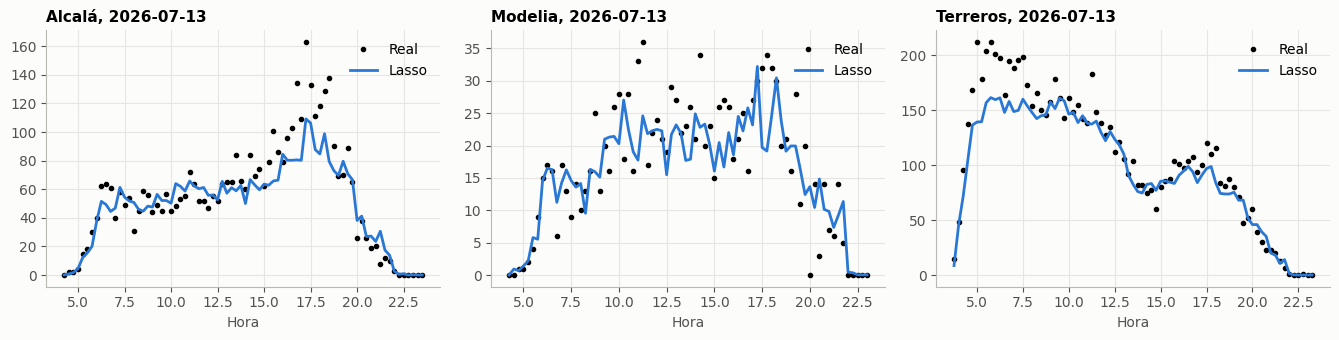

In [35]:
dia = sorted(dias_test)[len(dias_test) // 2]
est = [e for e in ESTUDIO.values() if (test.estacion == e).any()]
fig, ax = plt.subplots(1, len(est), figsize=(4.5 * len(est), 3.5), squeeze=False)
for a, e in zip(ax[0], est):
    m = ((test.fecha == dia) & (test.estacion == e)).to_numpy()
    a.plot(test.hora[m], real[m], "k.", label="Real")
    a.plot(test.hora[m], pred[mejor][m], label=mejor)
    a.set_title(f"{e}, {pd.Timestamp(dia).date()}"); a.set_xlabel("Hora"); a.legend()
plt.tight_layout(); plt.savefig(FIG / "real_vs_predicho.png", dpi=120); plt.show()

### 4.3 Decisión final (completar)

- **Ganador y por qué:** _métrica, variabilidad, interpretabilidad, costo de usarlo_.
- **¿Hubo empate dentro del margen de ruido?** _si sí, qué criterio lo desempató_.
- **Limitaciones:** _tres zonas, un trimestre, festivos, un solo horario GTFS para tres meses, oferta programada frente a la real_.

## Bloque 5. Fase 5: insumos para los informes

**Informe técnico** (`reports/informe_tecnico.md`): tablas en `data/processed/` (`resumen_carga`, `resultados_cv`, `hiperparametros`, `resultados_test`, `mae_por_estacion`, `bootstrap_mae`) y figuras en `reports/figuras/`.

**Informe gerencial** (`reports/informe_gerencial.md`): la celda siguiente traduce el error a pasajeros en cada estación de estudio y, si hay oferta, lo compara con los buses programados.

In [36]:
t_est = test[test.estudio].assign(prediccion=pred[mejor][es_estudio],
                                  error=np.abs(real - pred[mejor])[es_estudio])
resumen_g = t_est.groupby("estacion").agg(
    entradas_dia=("validaciones", lambda s: s.sum() / t_est.fecha.nunique()),
    error_promedio_por_franja=("error", "mean")).round(1)
display(resumen_g)

agg = {"esperado": ("prediccion", "mean")}
if "buses" in t_est:
    agg["buses"] = ("buses", "mean")
pico = (t_est[t_est.tipo_dia == "habil"].groupby(["estacion", "franja"]).agg(**agg)
        .reset_index().sort_values("esperado", ascending=False).groupby("estacion").head(3))
if "buses" in pico:
    pico["pasajeros_por_bus"] = (pico.esperado / pico.buses.where(pico.buses > 0)).round(0)
print("Las tres franjas de mayor demanda esperada en día hábil:"); display(pico.round(1))
resumen_g.to_csv(PROC / "resumen_gerencial.csv"); pico.to_csv(PROC / "franjas_pico.csv", index=False)

,entradas_dia,error_promedio_por_franja
estacion,,
Alcalá,15315.7,28.2
Modelia,4917.7,10.8
Terreros,21985.3,23.0


Las tres franjas de mayor demanda esperada en día hábil:


,estacion,franja,esperado,buses,pasajeros_por_bus
168,Terreros,06:30,1683.5,48.0,35.0
167,Terreros,06:15,1606.1,41.0,39.0
165,Terreros,05:45,1590.1,38.0,42.0
52,Alcalá,17:15,659.3,47.0,14.0
12,Alcalá,07:15,620.0,54.0,11.0
13,Alcalá,07:30,584.9,54.0,11.0
132,Modelia,17:15,282.0,30.0,9.0
131,Modelia,17:00,235.9,32.0,7.0
92,Modelia,07:15,200.0,42.0,5.0


### 5.1 Solo en Colab: subir tablas y figuras a GitHub
Pongan `SUBIR = True` cuando quieran guardar. El notebook se guarda aparte, con Archivo > Guardar una copia en GitHub.

In [37]:
SUBIR = False
if EN_COLAB and SUBIR:
    !git -C /content/{REPO} pull --rebase
    !git -C /content/{REPO} add data/processed reports
    !git -C /content/{REPO} commit -m "Resultados del notebook"
    !git -C /content/{REPO} push